# Análisis Comparativo Definitivo — 200 Preguntas Populares de España
## Google · ChatGPT con WebSearch · ChatGPT sin WebSearch

| Fuente | Descripción |
|---|---|
| **GPT+Search** | ChatGPT con búsqueda web activada |
| **GPT-NoSearch** | ChatGPT respondiendo solo con conocimiento interno |
| **Google** | Resultados orgánicos top-10 de Google Search |

**Dataset**: 200 preguntas populares locales de España, 15 categorías.

**Dimensiones de análisis**:
1. Cuántos links devuelve cada fuente
2. Similitud de dominios (Jaccard y sesgada) entre los tres pares
3. Qué tipo de webs prefiere cada motor
4. El fenómeno Wikipedia
5. Coincidencia de entidades nombradas
6. Análisis de posiciones por **URL normalizada** (metodología corregida)
7. GPT+Search vs GPT-NoSearch: ¿añade la web nueva información o solo confirma lo que ya sabe?

> **Nota metodológica importante**: El análisis de posiciones usa comparación por **URL exacta normalizada**,
> no por dominio. Comparar por dominio inflaba artificialmente las coincidencias GPT/Google
> (ej: ambos citan *algo* de Wikipedia pero artículos completamente distintos).
> Con URLs exactas: GPT+S vs Google pasa de 66 → 14 coincidencias reales.

---
## 0. Imports y configuración global

Cargamos todas las librerías necesarias y definimos la paleta de colores consistente
que se usará en todas las visualizaciones del notebook.

In [1]:
import pandas as pd
import re
import json as _json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from urllib.parse import unquote as _unquote
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# Paleta de colores: azul=GPT+Search, naranja=GPT-NoSearch, verde=Google, morado=par S/NS
COLORS = {
    'gpt_search':   '#2196F3',
    'gpt_nosearch': '#FF9800',
    'google':       '#4CAF50',
    'pair_s_ns':    '#9C27B0',
}
PAIR_COLORS = ['#9C27B0', '#F44336', '#607D8B']

print('✅ Imports y configuración listos.')

✅ Imports y configuración listos.


---
## 1. Carga y Preprocesamiento

Leemos los dos Excel:
- `200preguntas_datos_finales.xlsx`: contiene las respuestas de GPT+Search y los resultados de Google (columna `response` en JSON con rank+url+title).
- `200preguntas_locales_espana_gptsinsearch_.xlsx`: contiene las respuestas de GPT-NoSearch.

Definimos **todas las funciones de extracción y normalización** que se usarán a lo largo del notebook:

| Función | Qué hace |
|---|---|
| `get_urls_gpt` | Extrae URLs del formato `LinkItem(url='...')` de GPT |
| `get_names_gpt` | Extrae nombres de entidades del formato `LinkItem(name='...')` |
| `get_urls_google` | Extrae URLs del JSON de Google |
| `get_titles_google` | Extrae títulos del JSON de Google |
| `extract_google_ranked` | Extrae lista de `(rank, url)` del JSON de Google |
| `get_domain` | Limpia y extrae dominio de una URL |
| `normalize_url` | **Clave**: normaliza URLs para comparación exacta (quita www, %XX, variantes wiki) |
| `jaccard` | Índice de Jaccard entre dos listas |
| `sesgada` | Similitud sesgada: qué % de A aparece en B |

In [2]:
# ── Carga de datos ────────────────────────────────────────────────────────────
df_ns = pd.read_excel('200preguntas_locales_espana(gptsinsearch).xlsx')
df_s  = pd.read_excel('200preguntas_datos_finales.xlsx')

df_ns = df_ns[df_ns['Categoría'] != 'TOTAL'].reset_index(drop=True)
df_s  = df_s[df_s['Categoría']  != 'TOTAL'].reset_index(drop=True)

# ── Funciones de extracción ───────────────────────────────────────────────────
def get_urls_gpt(text):
    """Extrae URLs del formato LinkItem(url='https://...') que devuelve GPT."""
    if not isinstance(text, str): return []
    return re.findall(r"url='(.*?)'\)", text)

def get_names_gpt(text):
    """Extrae los nombres de entidades citadas por GPT (ej: 'McDonald\'s', 'Zara')."""
    if not isinstance(text, str): return []
    return re.findall(r"name='(.*?)'", text) + re.findall(r'name="(.*?)"', text)

def get_urls_google(text):
    """Extrae URLs del JSON de Google (campo 'url')."""
    if not isinstance(text, str): return []
    return re.findall(r'"url":\s*"(https?://[^"]+)"', text)

def get_titles_google(text):
    """Extrae los títulos de los resultados de Google."""
    if not isinstance(text, str): return []
    return re.findall(r'"title":\s*"([^"]+)"', text)

def extract_google_ranked(txt):
    """Extrae lista de (rank, url) del JSON de Google, preservando el orden de ranking."""
    if not isinstance(txt, str): return []
    try:
        items = _json.loads(txt)
        return [(int(d['rank']), d['url']) for d in items]
    except:
        return []

def get_domain(url):
    """Extrae el dominio limpio de una URL (sin www ni path)."""
    m = re.match(r'https?://([^/]+)', url)
    return m.group(1).replace('www.', '') if m else None

def normalize_url(url):
    """
    Normaliza una URL para comparación exacta entre fuentes:
    1. Elimina esquema (https://) y www.
    2. Elimina trailing slash
    3. Decodifica caracteres %XX (ej: %C3%A9 → é)
    4. Elimina desambiguaciones Wikipedia tipo _(Madrid), _(playa)
    5. Pasa a minúsculas

    Esto permite comparar:
    - Puerta_del_Sol == Puerta_del_Sol_(Madrid)  ✅
    - es.wikipedia.org/wiki/Madrid != es.wikipedia.org/wiki/Barcelona  ✅ (son artículos distintos)
    """
    url = url.strip().lower()
    url = re.sub(r'https?://(www\.)?', '', url)
    url = url.rstrip('/')
    url = _unquote(url)
    url = re.sub(r'_\([^)]+\)$', '', url)
    return url

def jaccard(a, b):
    """Jaccard simétrico: intersección / unión de dos conjuntos de URLs."""
    sa, sb = set(a), set(b)
    u = sa | sb
    return len(sa & sb) / len(u) if u else 0

def sesgada(a, b):
    """Similitud sesgada: qué porcentaje de los elementos de A aparecen también en B.
    Útil para responder: 'De lo que dice GPT, ¿cuánto confirma Google?'"""
    sa = set(a)
    return len(sa & set(b)) / len(sa) if sa else 0

# ── Construcción del DataFrame principal ──────────────────────────────────────
df = pd.DataFrame({
    'Categoría':        df_s['Categoría'],
    'Pregunta':         df_s['Pregunta'],
    'gpt_search_raw':   df_s['respuesta'],
    'gpt_nosearch_raw': df_ns['respuesta'],
    'google_raw':       df_s['response'],
})

# Extraer URLs, nombres y dominios para GPT+Search y GPT-NoSearch
for src in ['gpt_search', 'gpt_nosearch']:
    df[f'urls_{src}']  = df[f'{src}_raw'].apply(get_urls_gpt)
    df[f'names_{src}'] = df[f'{src}_raw'].apply(get_names_gpt)
    df[f'dom_{src}']   = df[f'urls_{src}'].apply(lambda l: [get_domain(u) for u in l if get_domain(u)])
    df[f'n_{src}']     = df[f'urls_{src}'].apply(len)

# Extraer URLs, títulos, dominios y ranking de Google
df['google_ranked'] = df['google_raw'].apply(extract_google_ranked)
df['urls_google']   = df['google_raw'].apply(get_urls_google)
df['titles_google'] = df['google_raw'].apply(get_titles_google)
df['dom_google']    = df['urls_google'].apply(lambda l: [get_domain(u) for u in l if get_domain(u)])
df['n_google']      = df['urls_google'].apply(len)

# ── Métricas de similitud por dominio y URL ───────────────────────────────────
# Calculamos Jaccard y similitud sesgada para los 3 pares posibles
PAIRS = [
    ('gpt_search',   'google',       'GPT+Search vs Google'),
    ('gpt_nosearch', 'google',       'GPT-NoSearch vs Google'),
    ('gpt_search',   'gpt_nosearch', 'GPT+Search vs GPT-NoSearch'),
]
for a, b, _ in PAIRS:
    k = f'{a}__{b}'
    df[f'jac_{k}']    = df.apply(lambda r: jaccard(r[f'urls_{a}'], r[f'urls_{b}']), axis=1)
    df[f'sg_url_{k}'] = df.apply(lambda r: sesgada(r[f'urls_{a}'], r[f'urls_{b}']), axis=1)
    df[f'sg_dom_{k}'] = df.apply(lambda r: sesgada(r[f'dom_{a}'],  r[f'dom_{b}']), axis=1)

# Jaccard de nombres (entidades) entre los dos GPT
df['names_jaccard'] = df.apply(
    lambda r: len(set(r['names_gpt_search']) & set(r['names_gpt_nosearch'])) /
              len(set(r['names_gpt_search']) | set(r['names_gpt_nosearch']))
              if (set(r['names_gpt_search']) | set(r['names_gpt_nosearch'])) else 0, axis=1)

print(f'✅ Dataset cargado: {len(df)} preguntas | {df["Categoría"].nunique()} categorías')
df[['Categoría','Pregunta','n_gpt_search','n_gpt_nosearch','n_google']].head(5)

✅ Dataset cargado: 201 preguntas | 15 categorías


,Categoría,Pregunta,n_gpt_search,n_gpt_nosearch,n_google
0,Restaurantes y Gastronomía,¿Cuáles son los restaurantes de comida rápida ...,6,7,10
1,Restaurantes y Gastronomía,¿Dónde están los mejores restaurantes de cocin...,1,5,10
2,Restaurantes y Gastronomía,¿Cuáles son los restaurantes con estrella Mich...,5,8,10
3,Restaurantes y Gastronomía,¿Dónde puedo comer la mejor paella en Valencia?,5,5,10
4,Restaurantes y Gastronomía,¿Cuáles son los bares de tapas más populares d...,5,5,10


---
## 2. Funciones de análisis de posición (URL normalizada)

Definimos las tres funciones que comparan **posiciones** entre pares de fuentes.
A diferencia del análisis de similitud de dominio anterior, aquí nos importa
no solo si coinciden, sino **en qué posición aparece cada URL en cada fuente**.

**Por qué URL normalizada y no dominio:**
- Si GPT cita `es.wikipedia.org/wiki/Madrid` y Google tiene `es.wikipedia.org/wiki/Barcelona`,
  comparar por dominio los contaría como coincidencia (ambos = `es.wikipedia.org`).
- Comparando por URL normalizada, son dos recursos distintos → no hay coincidencia real.
- Esto afecta especialmente a Wikipedia: el análisis por dominio inflaba hasta 66 coincidencias
  GPT+S/Google que en realidad son solo **14 URLs idénticas**.

`rank_diff = posición_A − posición_B`
- **Negativo**: A cita el recurso antes que B (A lo prioriza más)
- **Cero**: coinciden en la posición exacta
- **Positivo**: B lo cita antes (B lo prioriza más)

In [3]:
def pos_compare_url_s_ns(urls_s, urls_ns):
    """
    Compara GPT+Search vs GPT-NoSearch por URL normalizada.
    Para cada URL que aparece en ambas respuestas:
      - pos_s:     posición en GPT+Search (1 = primera citada)
      - pos_ns:    posición en GPT-NoSearch (1 = primera citada)
      - rank_diff: pos_s - pos_ns (negativo = GPT+S la pone antes)
    """
    norm_s  = {normalize_url(u): (i+1, u) for i, u in enumerate(urls_s)}
    norm_ns = {normalize_url(u): (i+1, u) for i, u in enumerate(urls_ns)}
    results = []
    for n in set(norm_s) & set(norm_ns):
        pos_s,  url_s  = norm_s[n]
        pos_ns, url_ns = norm_ns[n]
        results.append({
            'domain':    get_domain(url_s),
            'url':       url_s,
            'pos_s':     pos_s,
            'pos_ns':    pos_ns,
            'rank_diff': pos_s - pos_ns
        })
    return results

def pos_compare_gpt_google(gpt_urls, google_ranked):
    """
    Compara GPT (cualquier versión) vs Google por URL normalizada.
    Para cada URL que aparece en la respuesta GPT Y en los top-10 de Google:
      - gpt_position: posición en la respuesta GPT (1 = primera citada)
      - google_rank:  posición en Google (1 = primer resultado)
      - rank_diff:    gpt_position - google_rank
    """
    norm_gpt    = {normalize_url(u): (i+1, u) for i, u in enumerate(gpt_urls)}
    norm_google = {normalize_url(u): (rank, u) for rank, u in google_ranked}
    results = []
    for n in set(norm_gpt) & set(norm_google):
        gpt_pos, url_g  = norm_gpt[n]
        g_rank,  url_gg = norm_google[n]
        results.append({
            'domain':       get_domain(url_g),
            'url':          url_g,
            'gpt_position': gpt_pos,
            'google_rank':  g_rank,
            'rank_diff':    gpt_pos - g_rank
        })
    return results

# Aplicar las funciones al DataFrame
df['pos_s_ns'] = df.apply(lambda r: pos_compare_url_s_ns(r['urls_gpt_search'], r['urls_gpt_nosearch']), axis=1)
df['pos_s_g']  = df.apply(lambda r: pos_compare_gpt_google(r['urls_gpt_search'],   r['google_ranked']), axis=1)
df['pos_ns_g'] = df.apply(lambda r: pos_compare_gpt_google(r['urls_gpt_nosearch'], r['google_ranked']), axis=1)

# Aplanar a listas globales para análisis agregado
all_s_ns = [m for lst in df['pos_s_ns'] for m in lst]
all_s_g  = [m for lst in df['pos_s_g']  for m in lst]
all_ns_g = [m for lst in df['pos_ns_g'] for m in lst]

# También calcular versión por dominio (NB1) para comparación con NB2
df['n_shared_s_ns'] = df['pos_s_ns'].apply(len)

print("Coincidencias de URL exacta (normalizada) por par:")
print(f"  GPT+Search  vs GPT-NoSearch : {len(all_s_ns):>4} en {(df['pos_s_ns'].apply(len)>0).sum():>3} preguntas")
print(f"  GPT+Search  vs Google       : {len(all_s_g):>4} en {(df['pos_s_g'].apply(len)>0).sum():>3} preguntas")
print(f"  GPT-NoSearch vs Google      : {len(all_ns_g):>4} en {(df['pos_ns_g'].apply(len)>0).sum():>3} preguntas")
print()
print("⚠️  Comparativa con método antiguo (por dominio):")
print("   GPT+S vs Google: ~66 → 14  (las ~52 eran Wikipedia con artículos distintos)")
print("   GPT+S vs GPT-NS: ~305 → 310 (diferencia mínima, muy estable)")

Coincidencias de URL exacta (normalizada) por par:
  GPT+Search  vs GPT-NoSearch :  310 en 118 preguntas
  GPT+Search  vs Google       :   14 en  12 preguntas
  GPT-NoSearch vs Google      :   13 en  11 preguntas

⚠️  Comparativa con método antiguo (por dominio):
   GPT+S vs Google: ~66 → 14  (las ~52 eran Wikipedia con artículos distintos)
   GPT+S vs GPT-NS: ~305 → 310 (diferencia mínima, muy estable)


---
## 3. Cantidad de resultados por fuente

¿Cuántos links devuelve cada fuente por pregunta?
Esta es la base para entender la escala de cada sistema.
Google siempre devuelve exactamente 10. GPT varía según la pregunta.

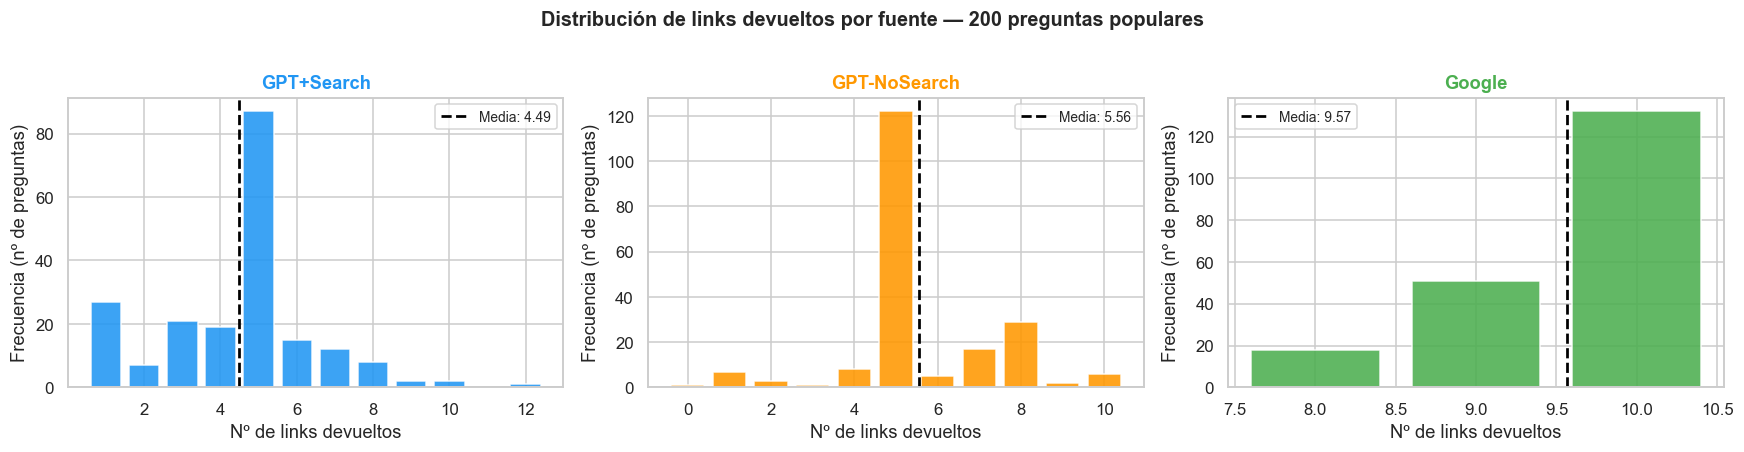

,Media,Mediana,Std,Min,Max,% sin resultados
Fuente,,,,,,
GPT+Search,4.49,5.0,2.02,1,12,0.0
GPT-NoSearch,5.56,5.0,1.77,0,10,0.5
Google,9.57,10.0,0.65,8,10,0.0


In [4]:
sources = [
    ('n_gpt_search',   'GPT+Search',   COLORS['gpt_search']),
    ('n_gpt_nosearch', 'GPT-NoSearch', COLORS['gpt_nosearch']),
    ('n_google',       'Google',       COLORS['google']),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (col, label, color) in zip(axes, sources):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=color, edgecolor='white', alpha=0.88)
    ax.axvline(df[col].mean(), color='black', linestyle='--', lw=1.8,
               label=f'Media: {df[col].mean():.2f}')
    ax.set_title(label, fontweight='bold', color=color)
    ax.set_xlabel('Nº de links devueltos')
    ax.set_ylabel('Frecuencia (nº de preguntas)')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de links devueltos por fuente — 200 preguntas populares',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla estadística resumen
rows = []
for col, label, _ in sources:
    s = df[col]
    rows.append({'Fuente': label, 'Media': round(s.mean(),2), 'Mediana': s.median(),
                 'Std': round(s.std(),2), 'Min': s.min(), 'Max': s.max(),
                 '% sin resultados': round((s==0).mean()*100, 1)})
pd.DataFrame(rows).set_index('Fuente')

---
## 4. Similitud global de URLs y dominios

Calculamos dos métricas de similitud para los 3 pares de fuentes y las comparamos
con el análisis previo de 10.000 preguntas locales.

- **Jaccard URL**: qué porcentaje de URLs totales son compartidas (simétrico)
- **Similitud Sesgada de Dominio**: de los dominios que cita A, qué % aparecen en B

> Paradoja esperada: las preguntas más famosas generan *menos* coincidencia URL con Google,
> porque para preguntas genéricas Google devuelve artículos editoriales y GPT devuelve
> la web oficial directamente.

Comparativa 200 preguntas populares vs 10.000 preguntas locales:


,Jaccard URL (200 pop.),Jaccard URL (10k local),Seg. Dominio (200 pop.),Seg. Dominio (10k local)
Par,,,,
GPT+Search vs Google,0.004700,0.032200,0.136700,0.342600
GPT-NoSearch vs Google,0.002600,0.002300,0.095400,0.154800
GPT+Search vs GPT-NoSearch,0.154800,0.005400,0.420900,0.079500


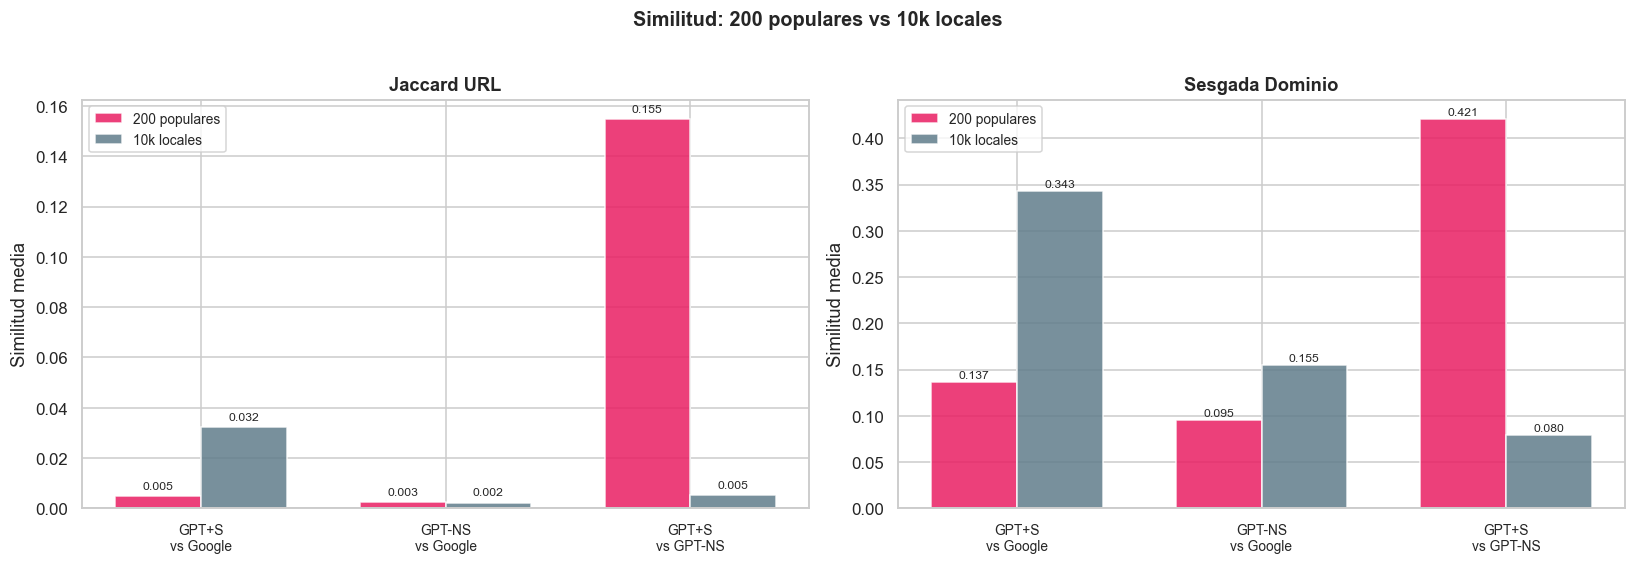

In [5]:
comparativa = pd.DataFrame({
    'Par': ['GPT+Search vs Google', 'GPT-NoSearch vs Google', 'GPT+Search vs GPT-NoSearch'],
    'Jaccard URL (200 pop.)': [
        df['jac_gpt_search__google'].mean(),
        df['jac_gpt_nosearch__google'].mean(),
        df['jac_gpt_search__gpt_nosearch'].mean(),
    ],
    'Jaccard URL (10k local)': [0.0322, 0.0023, 0.0054],
    'Seg. Dominio (200 pop.)': [
        df['sg_dom_gpt_search__google'].mean(),
        df['sg_dom_gpt_nosearch__google'].mean(),
        df['sg_dom_gpt_search__gpt_nosearch'].mean(),
    ],
    'Seg. Dominio (10k local)': [0.3426, 0.1548, 0.0795],
}).set_index('Par').round(4)

print('Comparativa 200 preguntas populares vs 10.000 preguntas locales:')
display(comparativa.style.background_gradient(cmap='RdYlGn', axis=1))

x = np.arange(3)
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (col200, col10k, title) in zip(axes, [
    ('Jaccard URL (200 pop.)', 'Jaccard URL (10k local)', 'Jaccard URL'),
    ('Seg. Dominio (200 pop.)', 'Seg. Dominio (10k local)', 'Sesgada Dominio'),
]):
    vals200 = comparativa[col200].values
    vals10k = comparativa[col10k].values
    b1 = ax.bar(x - width/2, vals200, width, label='200 populares', color='#E91E63', alpha=0.85, edgecolor='white')
    b2 = ax.bar(x + width/2, vals10k, width, label='10k locales',   color='#607D8B', alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(['GPT+S\nvs Google','GPT-NS\nvs Google','GPT+S\nvs GPT-NS'], fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Similitud media')
    ax.legend(fontsize=9)
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Similitud: 200 populares vs 10k locales', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Similitud de dominio por categoría y par

¿Hay categorías donde GPT y Google se parecen más? ¿Y entre los dos GPT?
Las barras muestran la **similitud sesgada de dominio media** para cada categoría.

Esperamos que Transporte/Turismo tengan alta coincidencia (hay webs "canónicas" como renfe.com)
y que Restaurantes tenga baja coincidencia (GPT cita webs oficiales, Google cita rankings).

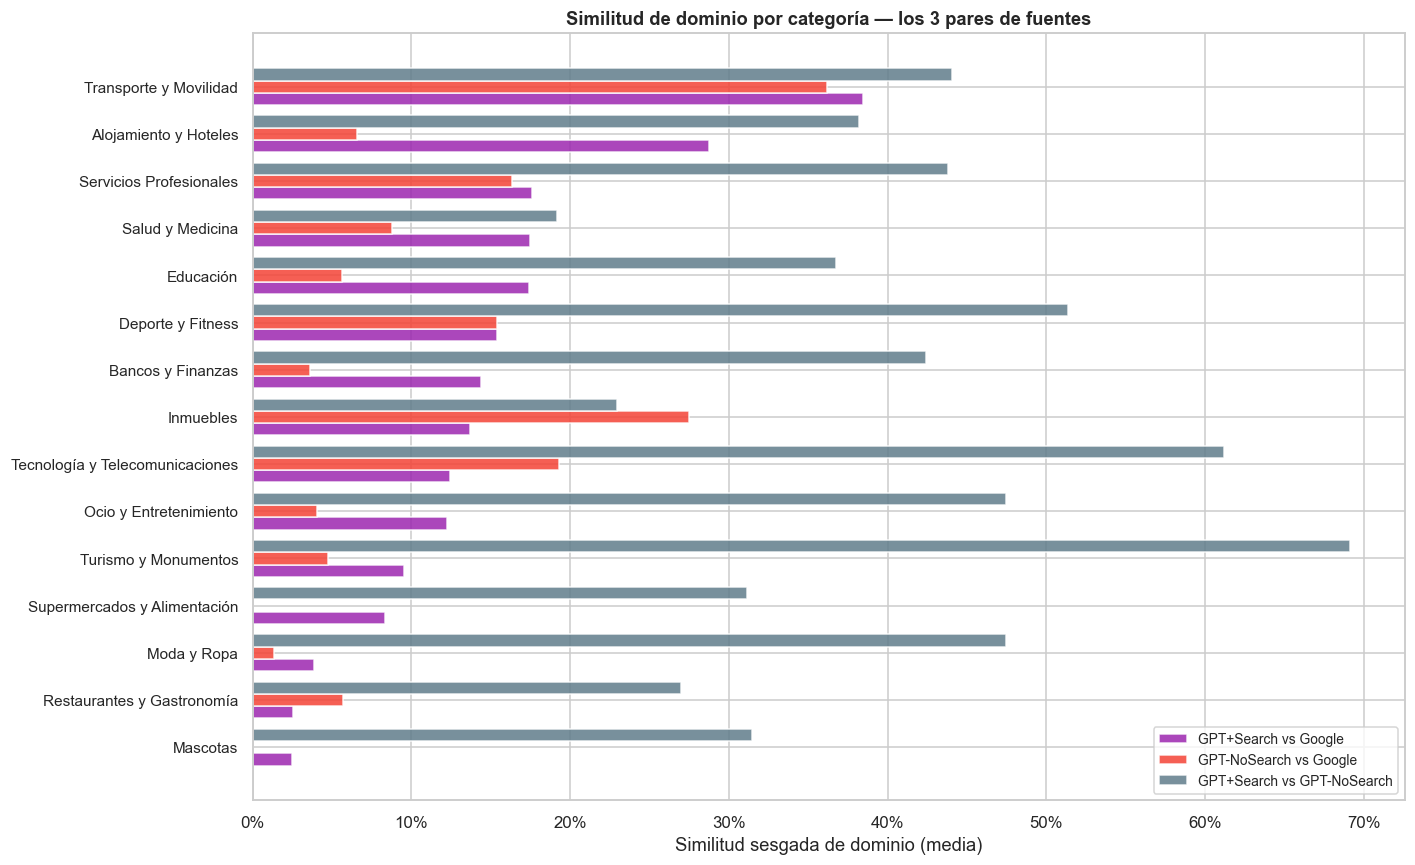

In [6]:
cat_order = df.groupby('Categoría')['sg_dom_gpt_search__google'].mean().sort_values().index

fig, ax = plt.subplots(figsize=(13, 8))
x = np.arange(len(cat_order))
w = 0.26

for i, ((a, b, label), color) in enumerate(zip(PAIRS, PAIR_COLORS)):
    k = f'{a}__{b}'
    vals = [df[df['Categoría']==cat][f'sg_dom_{k}'].mean() for cat in cat_order]
    ax.barh(x + i*w, vals, w, label=label, color=color, alpha=0.85, edgecolor='white')

ax.set_yticks(x + w)
ax.set_yticklabels(cat_order, fontsize=10)
ax.set_xlabel('Similitud sesgada de dominio (media)')
ax.set_title('Similitud de dominio por categoría — los 3 pares de fuentes',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

---
## 6. Heatmap de similitud por categoría y par

Vista de calor: cuanto más verde, mayor similitud de dominio entre el par.
Permite detectar de un vistazo qué pares de fuentes se solapan más en cada categoría.

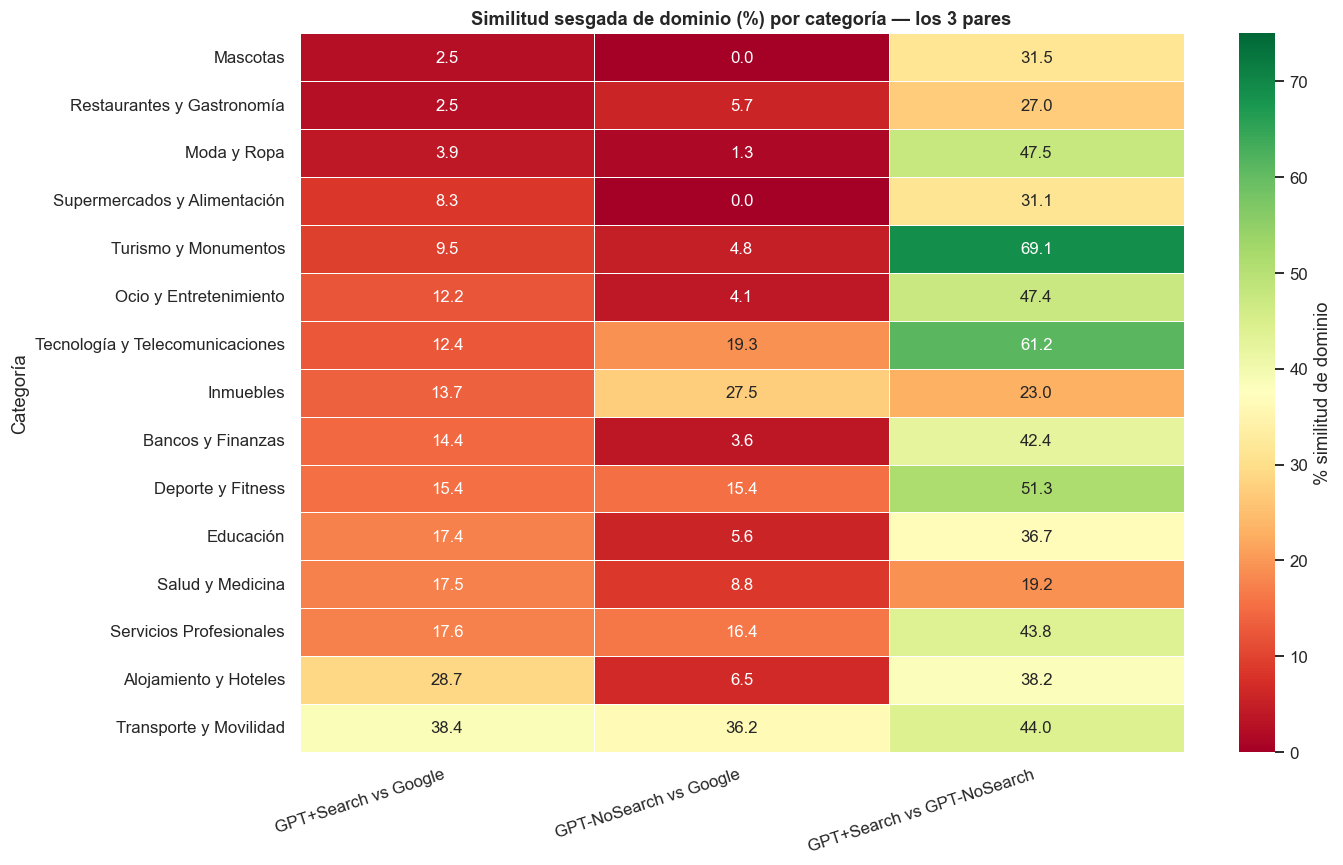

In [7]:
hm = pd.DataFrame({
    'GPT+Search vs Google':          df.groupby('Categoría')['sg_dom_gpt_search__google'].mean(),
    'GPT-NoSearch vs Google':        df.groupby('Categoría')['sg_dom_gpt_nosearch__google'].mean(),
    'GPT+Search vs GPT-NoSearch':    df.groupby('Categoría')['sg_dom_gpt_search__gpt_nosearch'].mean(),
}).sort_values('GPT+Search vs Google')

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(hm * 100, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, vmin=0, vmax=75,
            cbar_kws={'label': '% similitud de dominio'})
ax.set_title('Similitud sesgada de dominio (%) por categoría — los 3 pares',
             fontweight='bold', fontsize=12)
plt.xticks(rotation=18, ha='right')
plt.tight_layout()
plt.show()

---
## 7. Top dominios por fuente

¿Qué webs recomienda cada motor con más frecuencia en las 200 preguntas?
Esta visualización revela la **filosofía de respuesta** de cada fuente:
- GPT → webs enciclopédicas (Wikipedia) y webs oficiales
- Google → directorios de reseñas (TripAdvisor), medios y redes sociales

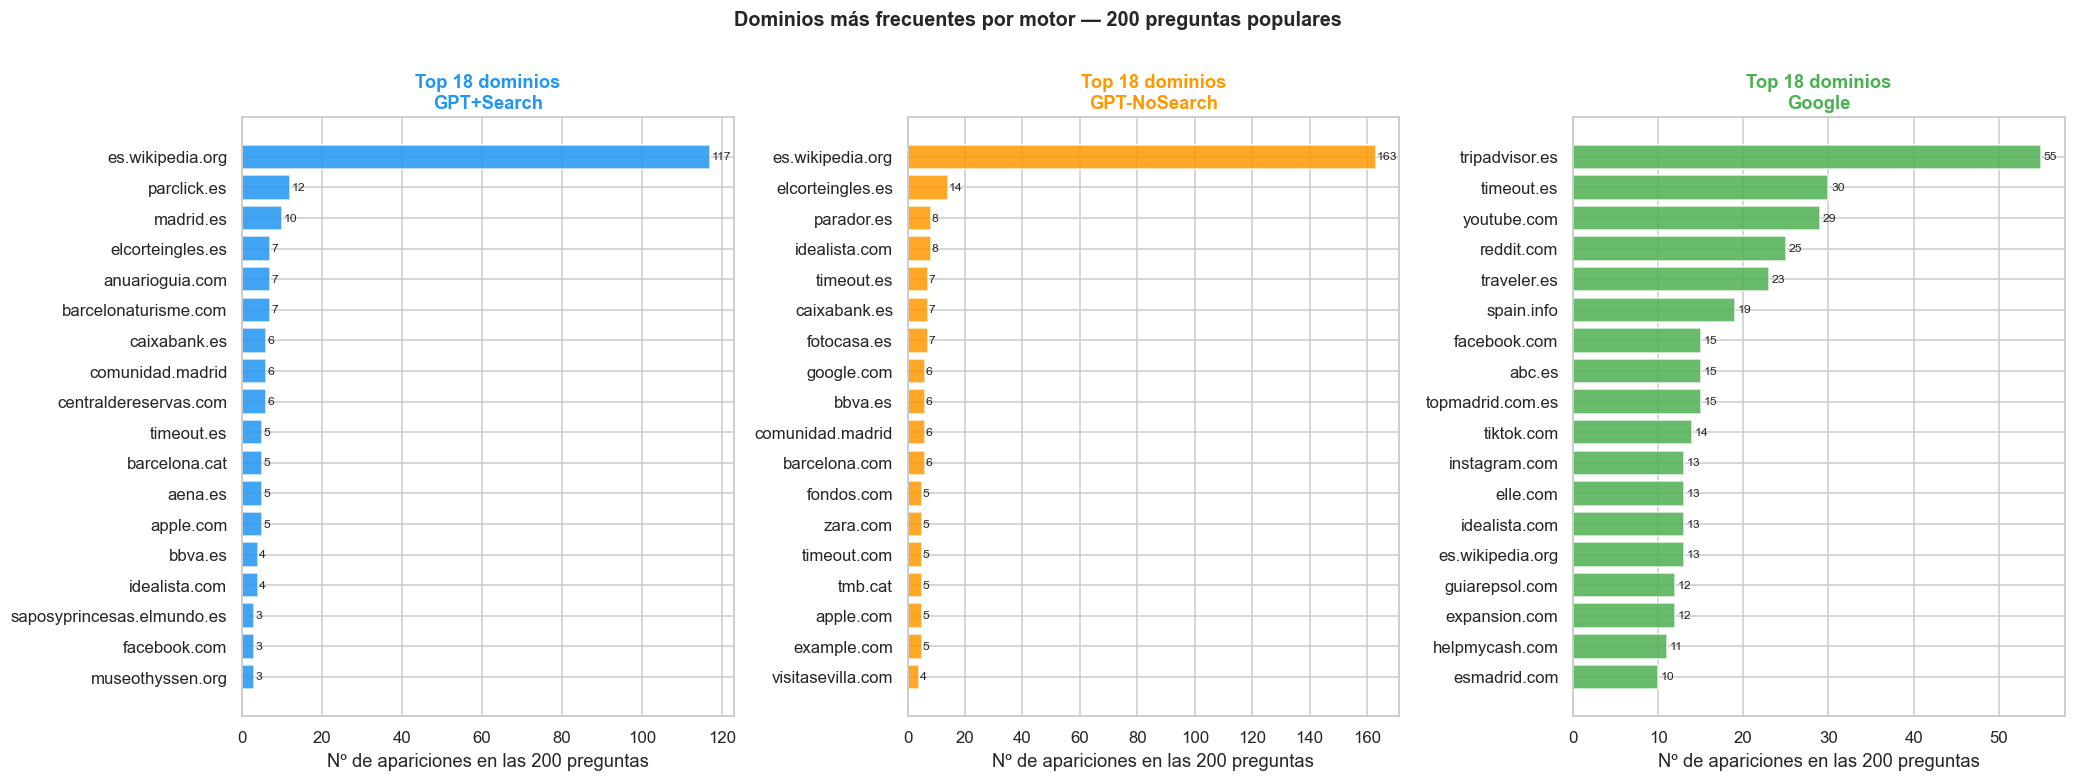


📌 Observaciones clave:
  • GPT (ambas versiones): es.wikipedia.org domina con diferencia
  • GPT-NoSearch: más elcorteingles.es y parador.es (conocimiento estático)
  • Google: tripadvisor.es, timeout.es, youtube.com y reddit.com lideran
  • Google: favorece contenido social/multimedia; GPT: webs informativas/oficiales


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(19, 7))

for ax, (col, label, color) in zip(axes, [
    ('dom_gpt_search',   'GPT+Search',   COLORS['gpt_search']),
    ('dom_gpt_nosearch', 'GPT-NoSearch', COLORS['gpt_nosearch']),
    ('dom_google',       'Google',       COLORS['google']),
]):
    all_d = [d for lst in df[col] for d in lst]
    top = Counter(all_d).most_common(18)
    domains = [d for d, _ in top][::-1]
    counts  = [c for _, c in top][::-1]
    ax.barh(domains, counts, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Top 18 dominios\n{label}', fontweight='bold', color=color)
    ax.set_xlabel('Nº de apariciones en las 200 preguntas')
    for i, (d, c) in enumerate(zip(domains, counts)):
        ax.text(c + 0.3, i, str(c), va='center', fontsize=8)

plt.suptitle('Dominios más frecuentes por motor — 200 preguntas populares',
             y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Observaciones clave:')
print('  • GPT (ambas versiones): es.wikipedia.org domina con diferencia')
print('  • GPT-NoSearch: más elcorteingles.es y parador.es (conocimiento estático)')
print('  • Google: tripadvisor.es, timeout.es, youtube.com y reddit.com lideran')
print('  • Google: favorece contenido social/multimedia; GPT: webs informativas/oficiales')

---
## 8. Clasificación por tipo de fuente

Agrupamos los dominios en categorías editoriales para entender la **estrategia de respuesta**
de cada motor más allá de los dominios individuales.

Categorías: Wikipedia/Enciclopedia · Oficial/Gobierno · Redes Sociales ·
Reseñas/Directorios · Medios/Prensa · Web Oficial Negocio · Inmuebles/Finanzas · Foros

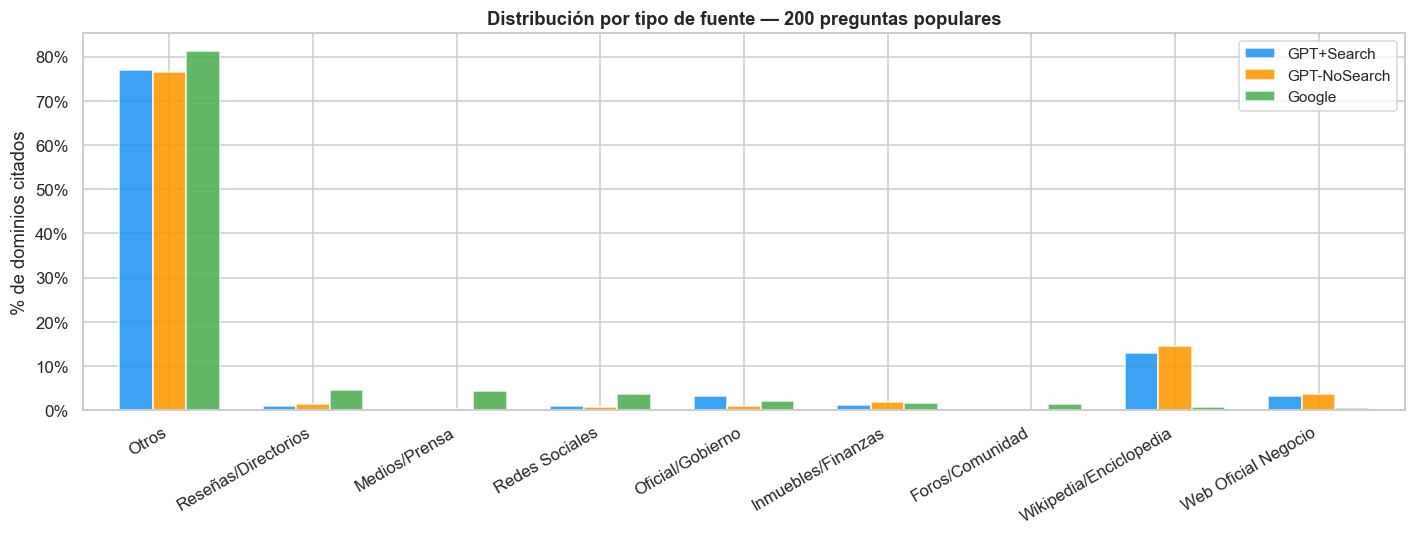


Distribución exacta (%):


,GPT+Search,GPT-NoSearch,Google
Otros,76.9,76.5,81.2
Reseñas/Directorios,1.0,1.3,4.6
Medios/Prensa,0.3,0.3,4.3
Redes Sociales,1.0,0.7,3.7
Oficial/Gobierno,3.3,1.0,2.1
Inmuebles/Finanzas,1.2,1.8,1.6
Foros/Comunidad,0.1,0.1,1.5
Wikipedia/Enciclopedia,13.0,14.6,0.7
Web Oficial Negocio,3.2,3.7,0.4


In [9]:
TIPOS = {
    'Wikipedia/Enciclopedia': ['es.wikipedia.org','wikipedia.org','es.m.wikipedia.org'],
    'Oficial/Gobierno':       ['madrid.es','barcelona.cat','comunidad.madrid','spain.info',
                               'aena.es','bde.es','renfe.com','esmadrid.com','visitvalencia.com'],
    'Redes Sociales':         ['instagram.com','facebook.com','tiktok.com','twitter.com','youtube.com'],
    'Reseñas/Directorios':    ['tripadvisor.es','tripadvisor.com','yelp.es','thefork.es',
                               'timeout.es','timeout.com','google.com/maps'],
    'Medios/Prensa':          ['abc.es','elpais.com','elmundo.es','traveler.es','elle.com',
                               'elespanol.com','expansion.com','marca.com','as.com'],
    'Web Oficial Negocio':    ['mcdonalds.es','burgerking.es','kfc.es','zara.com',
                               'elcorteingles.es','ikea.com','apple.com','caixabank.es',
                               'bbva.es','santander.es'],
    'Inmuebles/Finanzas':     ['idealista.com','fotocasa.es','habitaclia.com','pisos.com',
                               'helpmycash.com','ocu.org'],
    'Foros/Comunidad':        ['reddit.com','forocoches.com','es.quora.com','houzz.es'],
}

def classify_domain(dom):
    for tipo, doms in TIPOS.items():
        if dom in doms:
            return tipo
    return 'Otros'

tipo_counts = {}
for src in ['gpt_search','gpt_nosearch','google']:
    all_d = [d for lst in df[f'dom_{src}'] for d in lst]
    tipo_counts[src] = Counter([classify_domain(d) for d in all_d])

tipo_df = pd.DataFrame(tipo_counts).fillna(0)
tipo_df = tipo_df.div(tipo_df.sum()).round(3) * 100
tipo_df.columns = ['GPT+Search','GPT-NoSearch','Google']

fig, ax = plt.subplots(figsize=(13, 5))
tipo_df.sort_values('Google', ascending=False).plot(kind='bar', ax=ax,
    color=[COLORS['gpt_search'], COLORS['gpt_nosearch'], COLORS['google']],
    edgecolor='white', alpha=0.88, width=0.7)
ax.set_title('Distribución por tipo de fuente — 200 preguntas populares',
             fontweight='bold', fontsize=12)
ax.set_ylabel('% de dominios citados')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('\nDistribución exacta (%):')
display(tipo_df.sort_values('Google', ascending=False).round(1))

---
## 9. El fenómeno Wikipedia: GPT como enciclopedista

Wikipedia es el dominio más citado por GPT en las 200 preguntas populares.
¿Cuántas preguntas activan Wikipedia? ¿En qué categorías es más frecuente?

Importante: aunque aquí contamos apariciones de dominio (legítimo para este análisis),
en el análisis de posiciones usaremos URL exacta para no inflar coincidencias.

GPT+Search: Wikipedia en 23 preguntas (11.4%) | 117 apariciones de 903 totales (13.0%)
GPT-NoSearch: Wikipedia en 22 preguntas (10.9%) | 163 apariciones de 1117 totales (14.6%)
Google: Wikipedia en 12 preguntas (6.0%) | 13 apariciones de 1923 totales (0.7%)


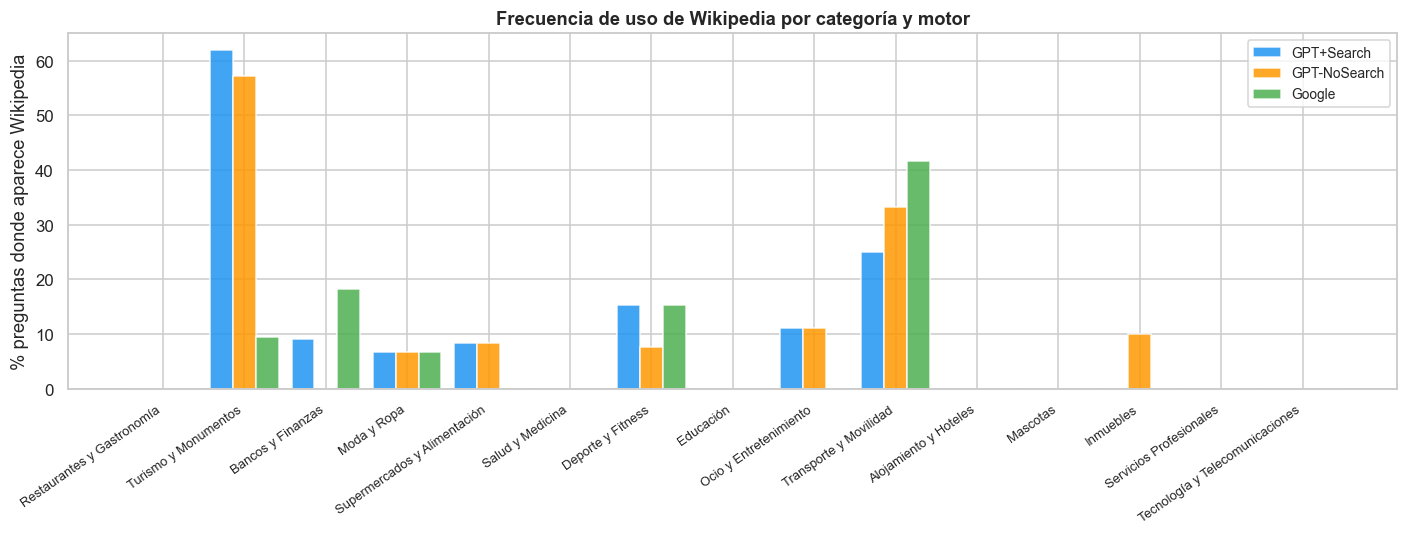

In [10]:
for src, label in [('gpt_search','GPT+Search'),('gpt_nosearch','GPT-NoSearch'),('google','Google')]:
    wiki_count = df[f'dom_{src}'].apply(lambda lst: 'es.wikipedia.org' in lst).sum()
    wiki_pct   = wiki_count / len(df) * 100
    total_dom  = sum(df[f'dom_{src}'].apply(len))
    wiki_total = sum(df[f'dom_{src}'].apply(lambda l: l.count('es.wikipedia.org')))
    print(f'{label}: Wikipedia en {wiki_count} preguntas ({wiki_pct:.1f}%) | '
          f'{wiki_total} apariciones de {total_dom} totales ({wiki_total/total_dom*100:.1f}%)')

fig, ax = plt.subplots(figsize=(13, 5))
cats = df['Categoría'].unique()
x = np.arange(len(cats))
w = 0.28

for i, (src, label, color) in enumerate([
    ('gpt_search',   'GPT+Search',   COLORS['gpt_search']),
    ('gpt_nosearch', 'GPT-NoSearch', COLORS['gpt_nosearch']),
    ('google',       'Google',       COLORS['google']),
]):
    vals = [df[df['Categoría']==cat][f'dom_{src}'].apply(
                lambda l: 'es.wikipedia.org' in l).mean()*100 for cat in cats]
    ax.bar(x + i*w, vals, w, label=label, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + w)
ax.set_xticklabels(cats, rotation=35, ha='right', fontsize=8.5)
ax.set_ylabel('% preguntas donde aparece Wikipedia')
ax.set_title('Frecuencia de uso de Wikipedia por categoría y motor', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 10. Coincidencia de entidades nombradas entre los dos GPT

Más allá de las URLs, ¿coinciden los dos GPT en **qué entidades recomendar**
(restaurantes, marcas, lugares)? El índice de Jaccard de nombres mide esto.

Un Jaccard alto significa que GPT+Search y GPT-NoSearch citan las mismas marcas/lugares,
aunque los links exactos sean distintos.

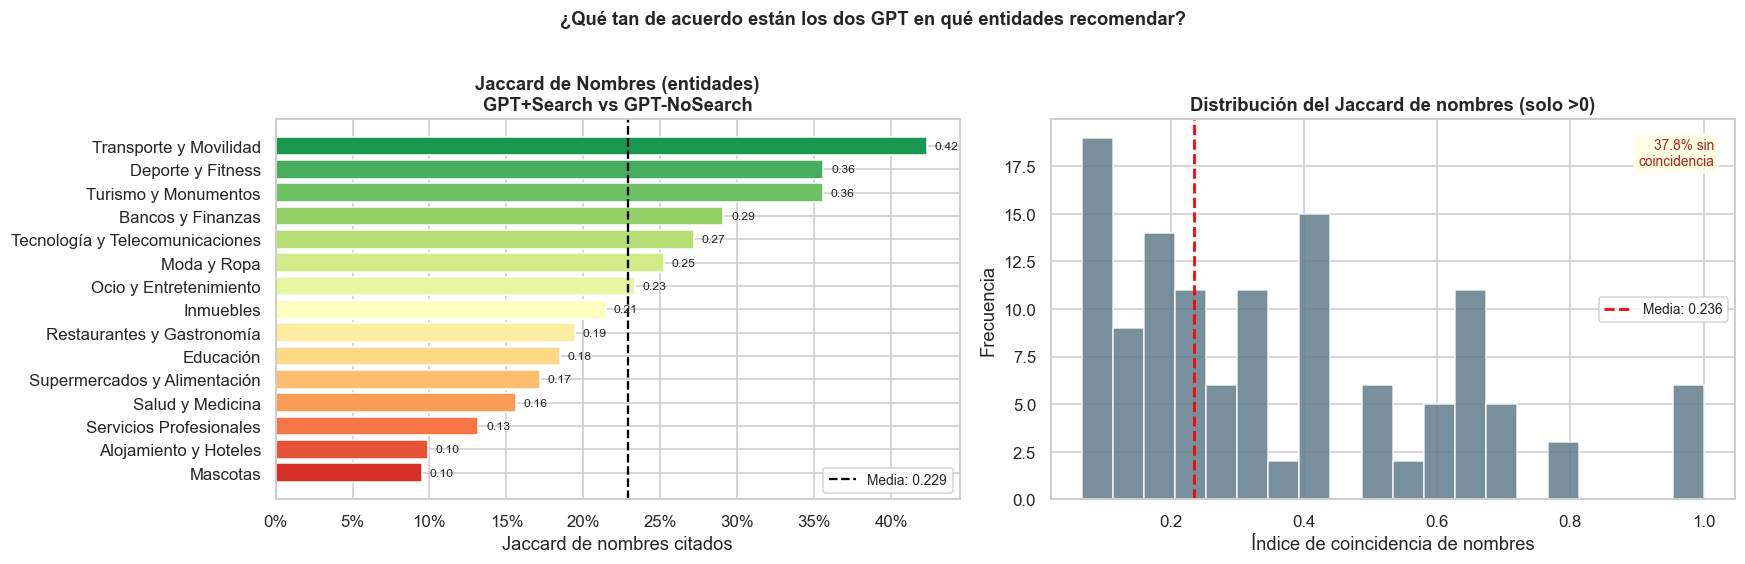

Jaccard medio de nombres: 0.236
Preguntas sin ningún nombre en común: 76 (37.8%)


In [11]:
cat_names = df.groupby('Categoría')['names_jaccard'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
colors_bar = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(cat_names)))
ax.barh(cat_names.index[::-1], cat_names.values[::-1], color=colors_bar, edgecolor='white')
ax.axvline(cat_names.mean(), color='black', linestyle='--', lw=1.5,
           label=f'Media: {cat_names.mean():.3f}')
ax.set_title('Jaccard de Nombres (entidades)\nGPT+Search vs GPT-NoSearch', fontweight='bold')
ax.set_xlabel('Jaccard de nombres citados')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(fontsize=9)
for i, v in enumerate(cat_names.values[::-1]):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=8)

ax2 = axes[1]
ax2.hist(df['names_jaccard'][df['names_jaccard']>0], bins=20, color='#607D8B', edgecolor='white', alpha=0.85)
ax2.axvline(df['names_jaccard'].mean(), color='red', linestyle='--', lw=1.8,
            label=f'Media: {df["names_jaccard"].mean():.3f}')
pct0 = (df['names_jaccard']==0).mean()*100
ax2.text(0.97, 0.95, f'{pct0:.1f}% sin\ncoincidencia', transform=ax2.transAxes,
         ha='right', va='top', fontsize=9, color='firebrick',
         bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.85))
ax2.set_title('Distribución del Jaccard de nombres (solo >0)', fontweight='bold')
ax2.set_xlabel('Índice de coincidencia de nombres')
ax2.set_ylabel('Frecuencia')
ax2.legend(fontsize=9)

plt.suptitle('¿Qué tan de acuerdo están los dos GPT en qué entidades recomendar?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Jaccard medio de nombres: {df["names_jaccard"].mean():.3f}')
print(f'Preguntas sin ningún nombre en común: {(df["names_jaccard"]==0).sum()} ({pct0:.1f}%)')

---
## 11. Top entidades nombradas por cada GPT

¿Qué marcas, lugares y negocios aparecen más en las respuestas de cada GPT?
Compara si la búsqueda web cambia el repertorio de entidades conocidas.

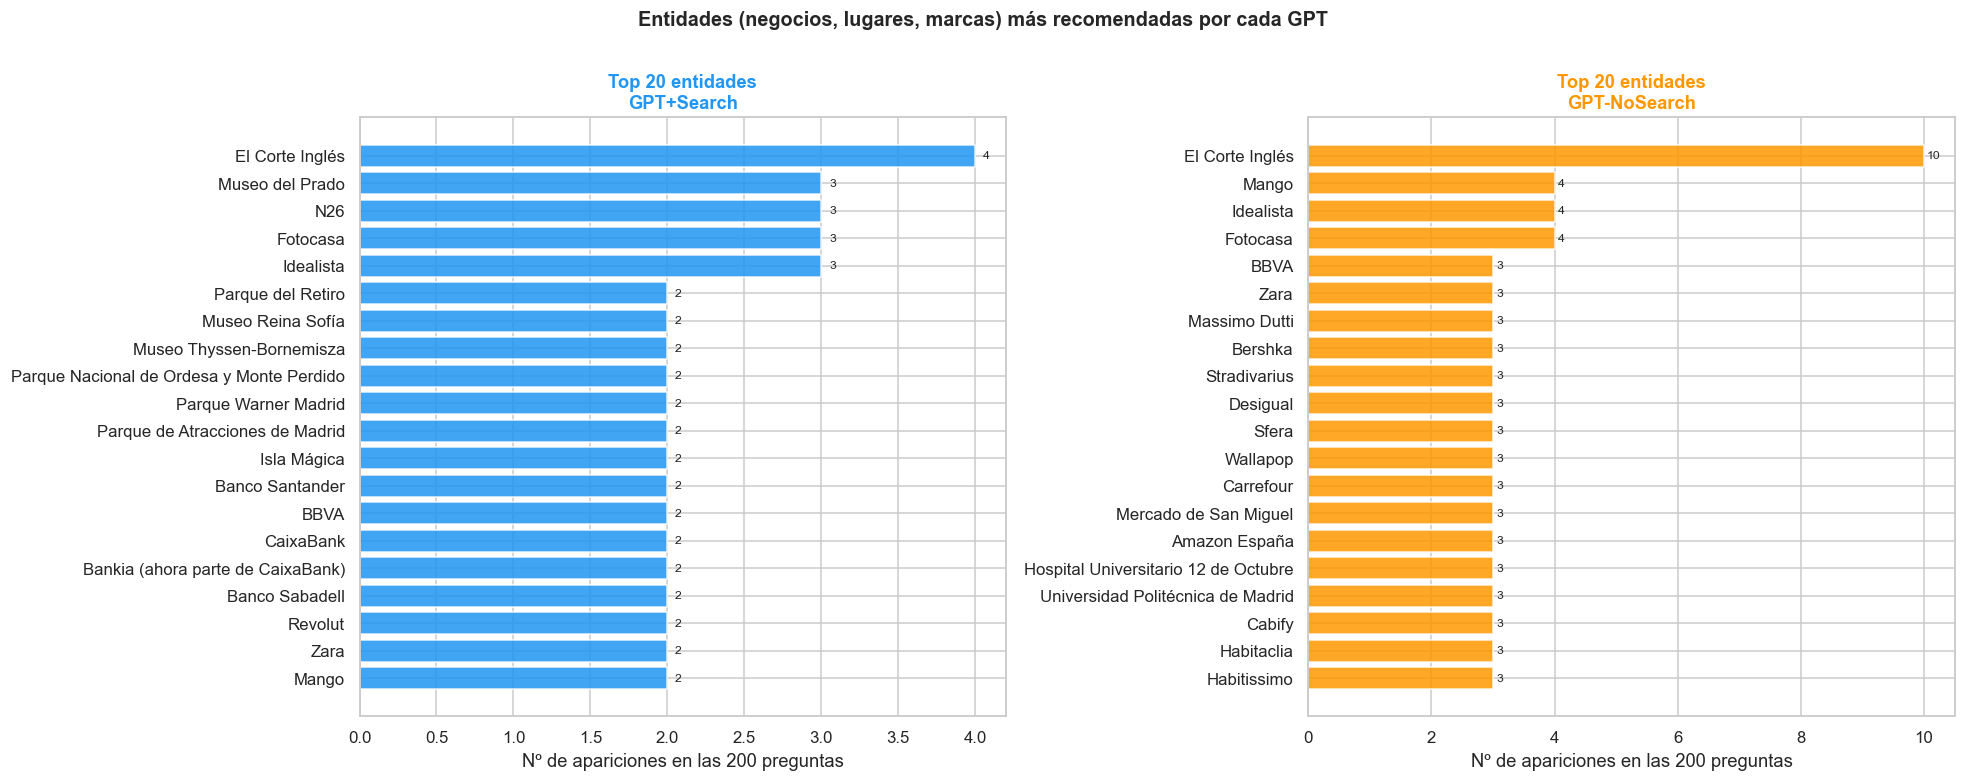

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (src, label, color) in zip(axes, [
    ('gpt_search',   'GPT+Search',   COLORS['gpt_search']),
    ('gpt_nosearch', 'GPT-NoSearch', COLORS['gpt_nosearch']),
]):
    all_n = [n for lst in df[f'names_{src}'] for n in lst]
    top = Counter(all_n).most_common(20)
    names  = [n for n, _ in top][::-1]
    counts = [c for _, c in top][::-1]
    ax.barh(names, counts, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Top 20 entidades\n{label}', fontweight='bold', color=color)
    ax.set_xlabel('Nº de apariciones en las 200 preguntas')
    for i, c in enumerate(counts):
        ax.text(c + 0.05, i, str(c), va='center', fontsize=8)

plt.suptitle('Entidades (negocios, lugares, marcas) más recomendadas por cada GPT',
             y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Dominios exclusivos: ¿qué añade la búsqueda web?

Para cada pregunta, identificamos dominios que aparecen **solo** en GPT+Search (activados
por la web) y dominios que aparecen **solo** en GPT-NoSearch (que la web desplaza o sustituye).

Usamos URL normalizada para no confundir "solo Wikipedia" con artículos distintos.

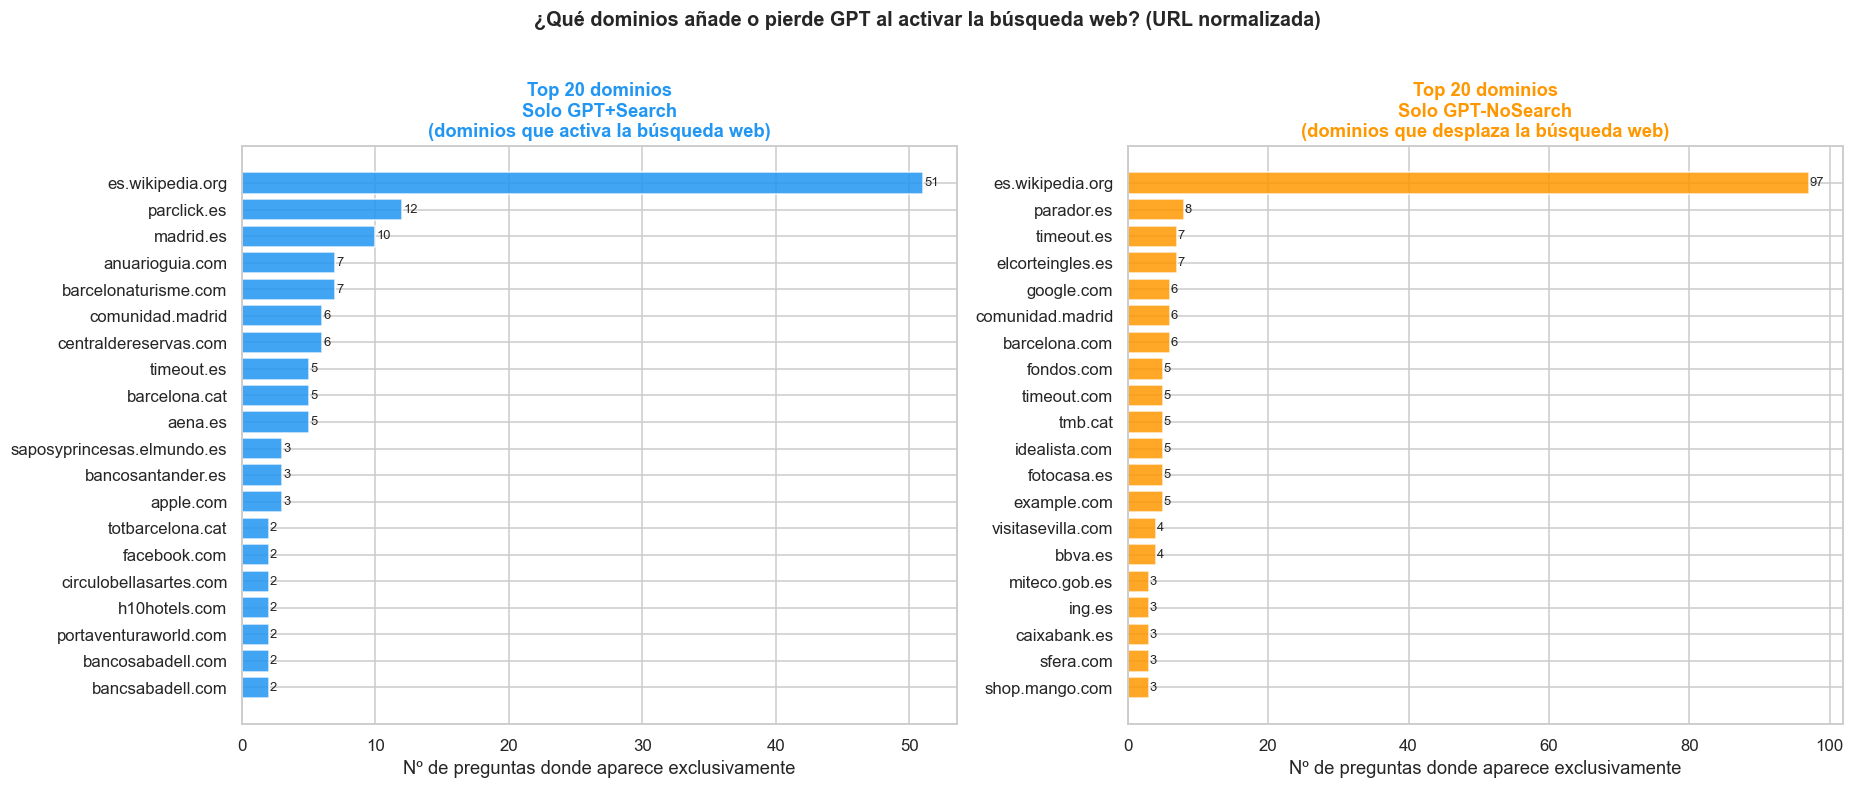


Top 10 dominios SOLO en GPT+Search:
  es.wikipedia.org: 51 preguntas
  parclick.es: 12 preguntas
  madrid.es: 10 preguntas
  anuarioguia.com: 7 preguntas
  barcelonaturisme.com: 7 preguntas
  comunidad.madrid: 6 preguntas
  centraldereservas.com: 6 preguntas
  timeout.es: 5 preguntas
  barcelona.cat: 5 preguntas
  aena.es: 5 preguntas

Top 10 dominios SOLO en GPT-NoSearch:
  es.wikipedia.org: 97 preguntas
  parador.es: 8 preguntas
  timeout.es: 7 preguntas
  elcorteingles.es: 7 preguntas
  google.com: 6 preguntas
  comunidad.madrid: 6 preguntas
  barcelona.com: 6 preguntas
  fondos.com: 5 preguntas
  timeout.com: 5 preguntas
  tmb.cat: 5 preguntas


In [13]:
only_s_doms, only_ns_doms = [], []
for _, r in df.iterrows():
    norms_s  = set(normalize_url(u) for u in r['urls_gpt_search'])
    norms_ns = set(normalize_url(u) for u in r['urls_gpt_nosearch'])
    for u in r['urls_gpt_search']:
        if normalize_url(u) not in norms_ns:
            only_s_doms.append(get_domain(u))
    for u in r['urls_gpt_nosearch']:
        if normalize_url(u) not in norms_s:
            only_ns_doms.append(get_domain(u))

top_only_s  = Counter(only_s_doms).most_common(20)
top_only_ns = Counter(only_ns_doms).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, data, label, color, subtitle in [
    (axes[0], top_only_s,  'Solo GPT+Search',   COLORS['gpt_search'],
     'dominios que activa la búsqueda web'),
    (axes[1], top_only_ns, 'Solo GPT-NoSearch', COLORS['gpt_nosearch'],
     'dominios que desplaza la búsqueda web'),
]:
    doms   = [d for d, _ in data][::-1]
    counts = [c for _, c in data][::-1]
    bars = ax.barh(doms, counts, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Top 20 dominios\n{label}\n({subtitle})', fontweight='bold', color=color)
    ax.set_xlabel('Nº de preguntas donde aparece exclusivamente')
    for bar, v in zip(bars, counts):
        ax.text(v+0.1, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=8.5)

plt.suptitle('¿Qué dominios añade o pierde GPT al activar la búsqueda web? (URL normalizada)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nTop 10 dominios SOLO en GPT+Search:')
for d, c in top_only_s[:10]:
    print(f'  {d}: {c} preguntas')
print('\nTop 10 dominios SOLO en GPT-NoSearch:')
for d, c in top_only_ns[:10]:
    print(f'  {d}: {c} preguntas')

---
## 13. Análisis cualitativo: máxima y mínima coincidencia con Google

Miramos caso a caso las preguntas donde GPT y Google más (y menos) se parecen.
Esto ilustra las diferencias filosóficas entre sistemas.

In [14]:
pd.set_option('display.max_colwidth', 90)

print('═'*90)
print('🟢 TOP 8 preguntas con MAYOR similitud de dominio: GPT+Search vs Google')
print('═'*90)
top8 = df[df['n_gpt_search']>0].nlargest(8, 'sg_dom_gpt_search__google')[
    ['Categoría','Pregunta','sg_dom_gpt_search__google','dom_gpt_search','dom_google']]
for _, r in top8.iterrows():
    print(f"  [{r['Categoría']}] {r['Pregunta'][:70]}")
    print(f"  Similitud: {r['sg_dom_gpt_search__google']:.0%}")
    print(f"  GPT+S:  {r['dom_gpt_search']}")
    print(f"  Google: {r['dom_google']}")
    print()

print('═'*90)
print('🔴 TOP 8 preguntas con CERO coincidencia (GPT tenía links pero ninguno en Google)')
print('═'*90)
bot8 = df[(df['n_gpt_search']>0) & (df['sg_dom_gpt_search__google']==0)].sample(8, random_state=42)[
    ['Categoría','Pregunta','dom_gpt_search','dom_google']]
for _, r in bot8.iterrows():
    print(f"  [{r['Categoría']}] {r['Pregunta'][:70]}")
    print(f"  GPT+S:  {r['dom_gpt_search']}")
    print(f"  Google: {r['dom_google']}")
    print()

══════════════════════════════════════════════════════════════════════════════════════════
🟢 TOP 8 preguntas con MAYOR similitud de dominio: GPT+Search vs Google
══════════════════════════════════════════════════════════════════════════════════════════
  [Turismo y Monumentos] ¿Cuáles son los pueblos más bonitos de España?
  Similitud: 100%
  GPT+S:  ['es.wikipedia.org', 'es.wikipedia.org', 'es.wikipedia.org', 'es.wikipedia.org', 'es.wikipedia.org']
  Google: ['lospueblosmasbonitosdeespana.org', 'viajes.nationalgeographic.com.es', 'skyscanner.es', 'travelvibes.es', 'es.wikipedia.org', 'lospueblosmasbonitosdeespana.org', 'sensacionrural.es', 'traveler.es', 'esquire.com']

  [Turismo y Monumentos] ¿Cuáles son los parques naturales más visitados de España?
  Similitud: 100%
  GPT+S:  ['es.wikipedia.org', 'es.wikipedia.org', 'es.wikipedia.org', 'es.wikipedia.org', 'es.wikipedia.org']
  Google: ['escapadarural.com', 'elespanol.com', 'expansion.com', 'wonderbox.es', 'es.hoteles.com', 'spain.

---
## 14. Posición: GPT+Search y GPT-NoSearch vs Google (scatter)

Para las 14 URLs exactas que GPT+Search comparte con Google (y las 13 de GPT-NoSearch),
¿en qué posición aparecen en cada fuente?

Si los sistemas priorizaran igual, todos los puntos caerían sobre la diagonal.
**La correlación Pearson r mide el grado de acuerdo en el orden.**

> Recuerda: son pocas coincidencias reales (14 URLs) porque GPT y Google citan recursos
> muy distintos, no porque compartan pocos dominios.

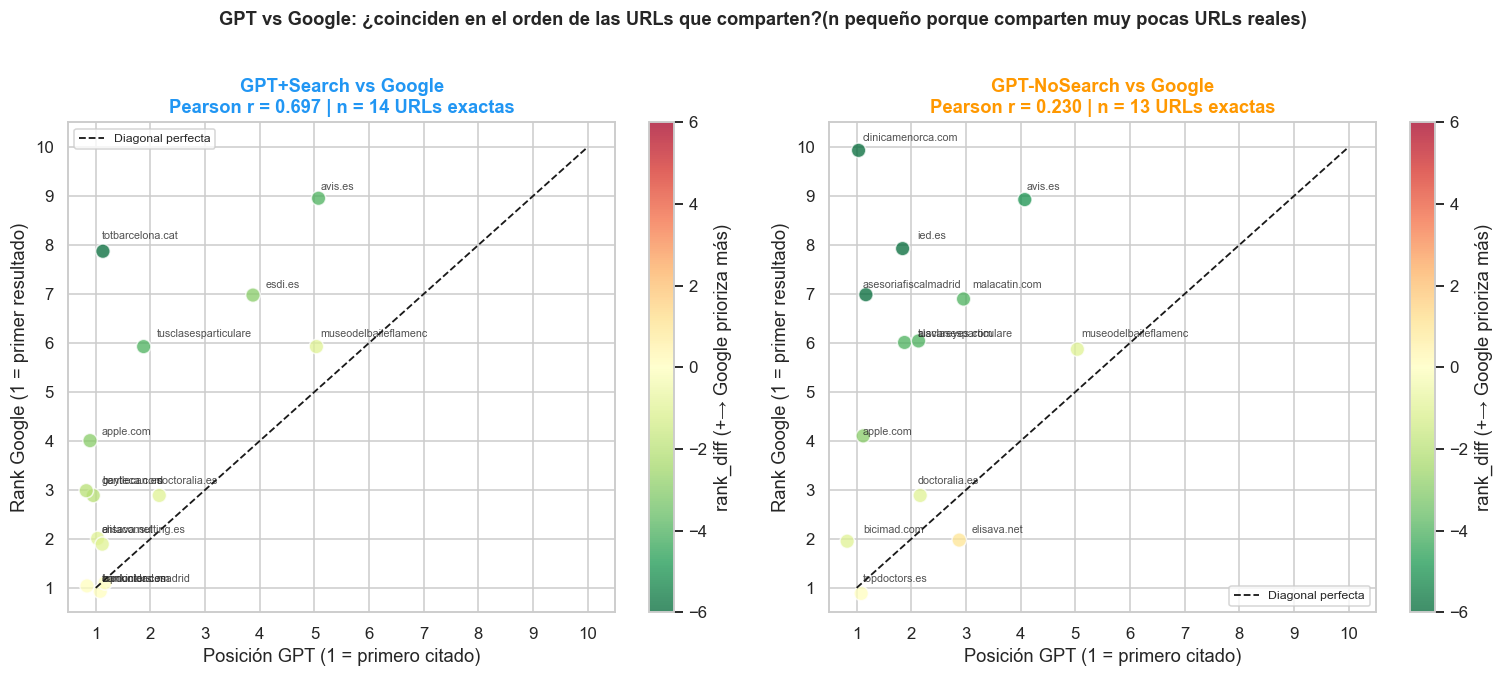


URLs exactas GPT+Search ↔ Google:
  Google#1 / GPT#1  diff=+0  https://www.topdoctors.es/
  Google#1 / GPT#1  diff=+0  https://www.comunidad.madrid/servicios/educacion/formacion-profesional
  Google#1 / GPT#1  diff=+0  https://www.bankinter.com/blog/finanzas-personales/comprar-casa-barata-madr
  Google#2 / GPT#1  diff=-1  https://www.elisava.net/
  Google#2 / GPT#1  diff=-1  https://www.antaconsulting.es/asesoria-fiscal-madrid/
  Google#3 / GPT#1  diff=-2  https://www.bayteca.com/hipotecas/mejores-hipotecas-espana-2026/
  Google#3 / GPT#2  diff=-1  https://www.doctoralia.es/
  Google#3 / GPT#1  diff=-2  https://gentlecan.es/
  Google#4 / GPT#1  diff=-3  https://www.apple.com/es/retail/puertadelsol/
  Google#6 / GPT#2  diff=-4  https://www.tusclasesparticulares.com/
  Google#6 / GPT#5  diff=-1  https://www.museodelbaileflamenco.com/
  Google#7 / GPT#4  diff=-3  https://www.esdi.es/
  Google#8 / GPT#1  diff=-7  https://www.totbarcelona.cat/es/sociedad/las-mejores-guarderias-publicas-de


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, label, color in [
    (axes[0], all_s_g,  'GPT+Search vs Google',   COLORS['gpt_search']),
    (axes[1], all_ns_g, 'GPT-NoSearch vs Google',  COLORS['gpt_nosearch']),
]:
    if not data:
        ax.set_title(f'Sin datos suficientes\n{label}'); continue

    gpt_pos = [m['gpt_position'] for m in data]
    g_rank  = [m['google_rank']  for m in data]

    np.random.seed(42)
    jx = np.array(gpt_pos, float) + np.random.uniform(-0.18, 0.18, len(gpt_pos))
    jy = np.array(g_rank,  float) + np.random.uniform(-0.18, 0.18, len(g_rank))

    sc = ax.scatter(jx, jy, c=[m['rank_diff'] for m in data], cmap='RdYlGn_r',
                    alpha=0.75, s=90, edgecolor='white', vmin=-6, vmax=6)
    ax.plot([1, 10], [1, 10], 'k--', lw=1.2, label='Diagonal perfecta')
    plt.colorbar(sc, ax=ax, label='rank_diff (+→ Google prioriza más)')

    corr = np.corrcoef(gpt_pos, g_rank)[0, 1] if len(gpt_pos) > 2 else float('nan')
    ax.set_title(f'{label}\nPearson r = {corr:.3f} | n = {len(data)} URLs exactas',
                 fontweight='bold', color=color)
    ax.set_xlabel('Posición GPT (1 = primero citado)')
    ax.set_ylabel('Rank Google (1 = primer resultado)')
    ax.set_xlim(0.5, 10.5); ax.set_ylim(0.5, 10.5)
    ax.set_xticks(range(1,11)); ax.set_yticks(range(1,11))
    ax.legend(fontsize=8)

    # Anotar los dominios
    for m in data:
        ax.annotate(m['domain'][:20], (m['gpt_position'], m['google_rank']),
                    fontsize=7, alpha=0.8, xytext=(4,4), textcoords='offset points')

plt.suptitle('GPT vs Google: ¿coinciden en el orden de las URLs que comparten?(n pequeño porque comparten muy pocas URLs reales)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nURLs exactas GPT+Search ↔ Google:')
for m in sorted(all_s_g, key=lambda x: x['google_rank']):
    print(f"  Google#{m['google_rank']} / GPT#{m['gpt_position']}  diff={m['rank_diff']:+d}  {m['url'][:75]}")
if all_ns_g:
    print('\nURLs exactas GPT-NoSearch ↔ Google:')
    for m in sorted(all_ns_g, key=lambda x: x['google_rank']):
        print(f"  Google#{m['google_rank']} / GPT#{m['gpt_position']}  diff={m['rank_diff']:+d}  {m['url'][:75]}")

---
## 15. ¿En qué posición de Google están las URLs que cita GPT?

Cuando GPT cita una URL que también aparece en Google (exactamente la misma),
¿en qué posición suele estar en Google?
Nos dice si GPT tiende a citar lo que Google considera más relevante (top 3)
o recursos que Google relega a posiciones bajas.

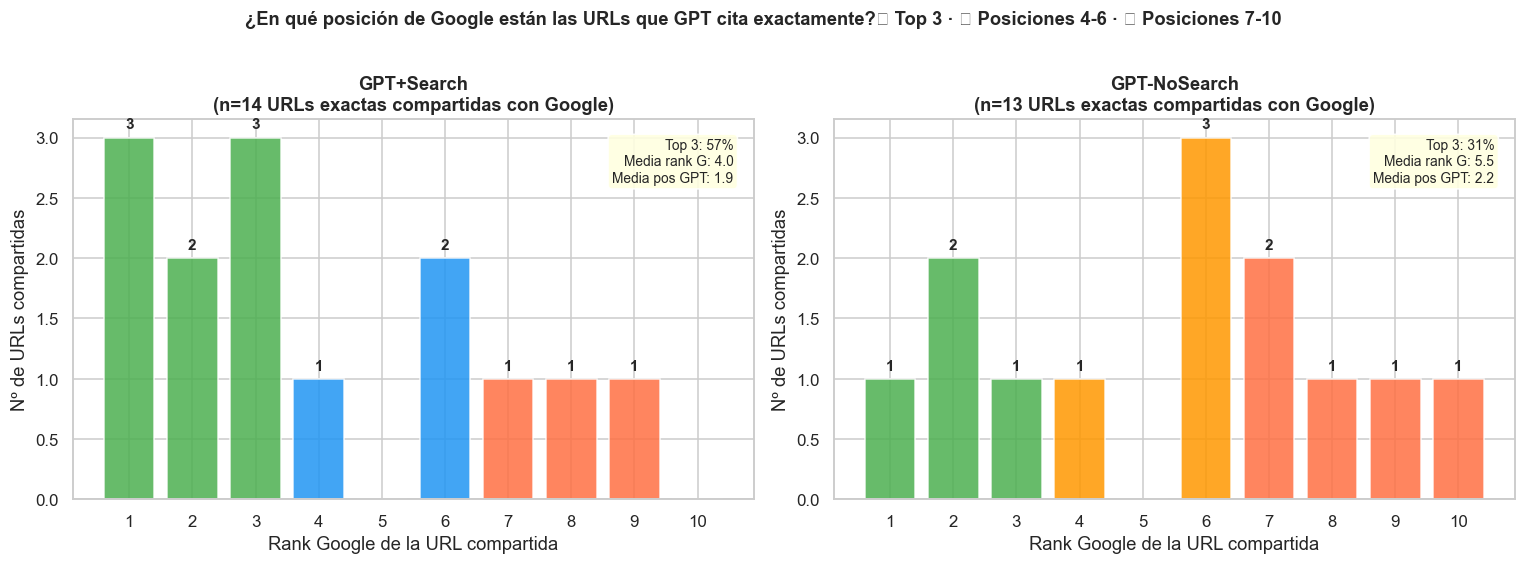

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label, color in [
    (axes[0], all_s_g,  'GPT+Search',   COLORS['gpt_search']),
    (axes[1], all_ns_g, 'GPT-NoSearch', COLORS['gpt_nosearch']),
]:
    if not data:
        ax.set_title(f'Sin datos suficientes\n{label}'); continue

    g_ranks     = [m['google_rank'] for m in data]
    gpt_pos     = [m['gpt_position'] for m in data]
    rank_counts = Counter(g_ranks)

    x_vals = range(1, 11)
    y_vals = [rank_counts.get(r, 0) for r in x_vals]
    bars = ax.bar(x_vals, y_vals, color=color, edgecolor='white', alpha=0.85)
    for bar, r in zip(bars, x_vals):
        if r <= 3:   bar.set_facecolor('#4CAF50')
        elif r <= 6: bar.set_facecolor(color)
        else:        bar.set_facecolor('#FF7043')

    ax.set_xticks(list(x_vals))
    ax.set_xlabel('Rank Google de la URL compartida')
    ax.set_ylabel('Nº de URLs compartidas')
    ax.set_title(f'{label}\n(n={len(data)} URLs exactas compartidas con Google)', fontweight='bold')

    if data:
        top3 = sum(rank_counts.get(r,0) for r in range(1,4)) / len(data) * 100
        ax.text(0.97, 0.95,
                f'Top 3: {top3:.0f}%\nMedia rank G: {np.mean(g_ranks):.1f}\nMedia pos GPT: {np.mean(gpt_pos):.1f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

    for bar, v in zip(bars, y_vals):
        if v: ax.text(bar.get_x()+bar.get_width()/2, v+0.05, str(v),
                      ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('¿En qué posición de Google están las URLs que GPT cita exactamente?🟢 Top 3 · 🟡 Posiciones 4-6 · 🔴 Posiciones 7-10',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 16. Posición: GPT+Search vs GPT-NoSearch (scatter)

Con 310 URLs exactas compartidas entre los dos GPT en 118 preguntas, tenemos
suficiente masa para analizar si el orden de citación es similar.

Alta correlación aquí significaría que **la búsqueda web no cambia la priorización**,
solo amplía el catálogo de recursos conocidos.

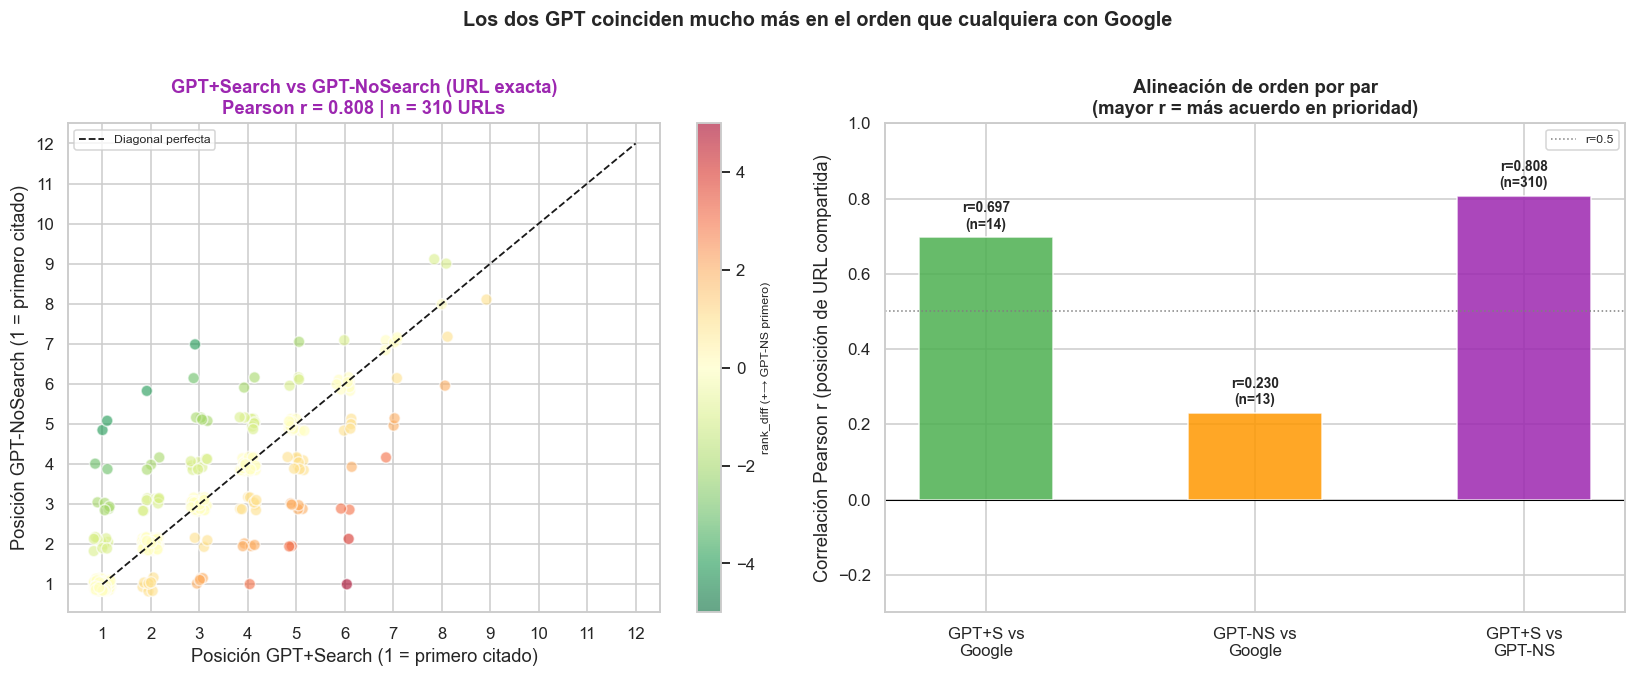

r GPT+S vs Google   = 0.697  (n=14)
r GPT-NS vs Google  = 0.230  (n=13)
r GPT+S vs GPT-NS   = 0.808  (n=310)


In [17]:
pos_s_vals  = [m['pos_s']  for m in all_s_ns]
pos_ns_vals = [m['pos_ns'] for m in all_s_ns]
diff_s_ns   = [m['rank_diff'] for m in all_s_ns]
r_s_ns = float(np.corrcoef(pos_s_vals, pos_ns_vals)[0,1]) if len(pos_s_vals) > 2 else float('nan')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Scatter GPT+S vs GPT-NS ───────────────────────────────────────────────────
ax = axes[0]
np.random.seed(42)
jx = np.array(pos_s_vals,  float) + np.random.uniform(-0.18, 0.18, len(pos_s_vals))
jy = np.array(pos_ns_vals, float) + np.random.uniform(-0.18, 0.18, len(pos_ns_vals))

sc = ax.scatter(jx, jy, c=diff_s_ns, cmap='RdYlGn_r', alpha=0.6,
                s=55, edgecolor='white', vmin=-5, vmax=5)
ax.plot([1,12],[1,12], 'k--', lw=1.2, label='Diagonal perfecta')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('rank_diff (+→ GPT-NS primero)', fontsize=8)
ax.set_title(f'GPT+Search vs GPT-NoSearch (URL exacta)\nPearson r = {r_s_ns:.3f} | n = {len(all_s_ns)} URLs',
             fontweight='bold', color=COLORS['pair_s_ns'])
ax.set_xlabel('Posición GPT+Search (1 = primero citado)')
ax.set_ylabel('Posición GPT-NoSearch (1 = primero citado)')
ax.set_xlim(0.3, 12.5); ax.set_ylim(0.3, 12.5)
ax.set_xticks(range(1,13)); ax.set_yticks(range(1,13))
ax.legend(fontsize=8)

# ── Comparativa de r entre los 3 pares ───────────────────────────────────────
ax2 = axes[1]

def calc_r(data, col_a, col_b):
    if len(data) < 3: return float('nan')
    a = [m[col_a] for m in data]
    b = [m[col_b] for m in data]
    return float(np.corrcoef(a, b)[0,1])

pares_r = [
    ('GPT+S vs\nGoogle',    calc_r(all_s_g,  'gpt_position','google_rank'), len(all_s_g),  COLORS['google']),
    ('GPT-NS vs\nGoogle',   calc_r(all_ns_g, 'gpt_position','google_rank'), len(all_ns_g), COLORS['gpt_nosearch']),
    ('GPT+S vs\nGPT-NS',    r_s_ns,                                          len(all_s_ns), COLORS['pair_s_ns']),
]

bars = ax2.bar([p[0] for p in pares_r], [p[1] for p in pares_r],
               color=[p[3] for p in pares_r], alpha=0.85, edgecolor='white', width=0.5)
for bar, (_, rv, nv, _) in zip(bars, pares_r):
    if not np.isnan(rv):
        ax2.text(bar.get_x()+bar.get_width()/2, rv + 0.015,
                 f'r={rv:.3f}\n(n={nv})', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.set_ylim(-0.3, 1.0)
ax2.axhline(0.5, color='gray', linestyle=':', lw=1, label='r=0.5')
ax2.axhline(0.0, color='black', linestyle='-', lw=0.7)
ax2.set_ylabel('Correlación Pearson r (posición de URL compartida)')
ax2.set_title('Alineación de orden por par\n(mayor r = más acuerdo en prioridad)', fontweight='bold')
ax2.legend(fontsize=8)

plt.suptitle('Los dos GPT coinciden mucho más en el orden que cualquiera con Google',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'r GPT+S vs Google   = {calc_r(all_s_g,  "gpt_position","google_rank"):.3f}  (n={len(all_s_g)})')
print(f'r GPT-NS vs Google  = {calc_r(all_ns_g, "gpt_position","google_rank"):.3f}  (n={len(all_ns_g)})')
print(f'r GPT+S vs GPT-NS   = {r_s_ns:.3f}  (n={len(all_s_ns)})')

---
## 17. Distribución de diferencias de posición — los 3 pares

`rank_diff = pos_A − pos_B`
- **Azul (negativo)**: A cita el recurso antes que B
- **Amarillo (cero)**: misma posición exacta
- **Rojo (positivo)**: B cita el recurso antes

Mostramos los 3 pares en paralelo para comparar cuál tiene más simetría
y cuál tiende a que una fuente priorice más.

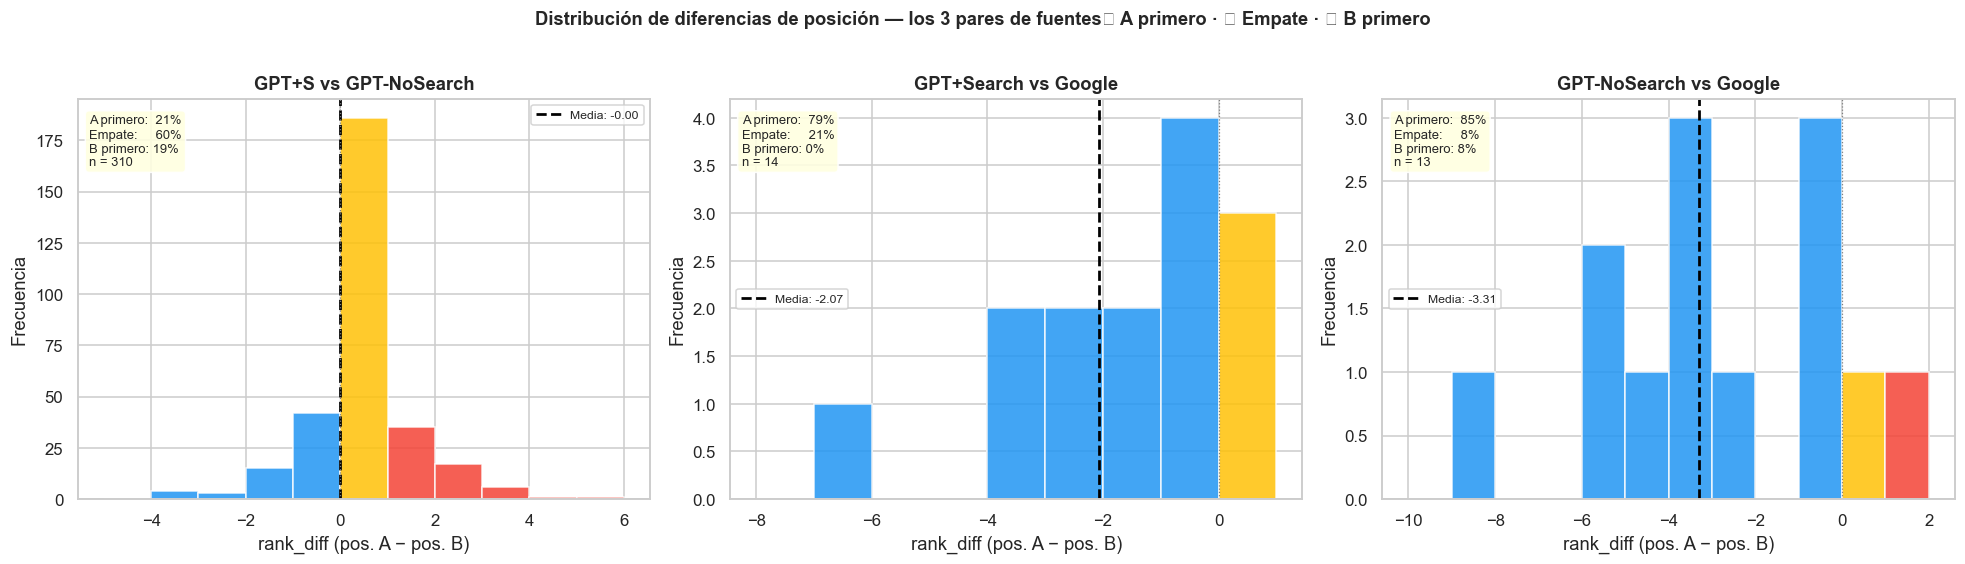

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pares_hist = [
    ('GPT+S vs GPT-NoSearch',
     [m['rank_diff'] for m in all_s_ns], COLORS['pair_s_ns']),
    ('GPT+Search vs Google',
     [m['rank_diff'] for m in all_s_g],  COLORS['gpt_search']),
    ('GPT-NoSearch vs Google',
     [m['rank_diff'] for m in all_ns_g], COLORS['gpt_nosearch']),
]

for ax, (label, diffs, color) in zip(axes, pares_hist):
    if not diffs:
        ax.set_title(f'Sin datos suficientes\n{label}'); continue

    mn, mx = int(min(diffs)), int(max(diffs))
    n_h, _, patches = ax.hist(diffs, bins=range(mn-1, mx+2), edgecolor='white', alpha=0.85)
    for patch, b in zip(patches, range(mn-1, mx+2)):
        if b < 0:    patch.set_facecolor('#2196F3')
        elif b == 0: patch.set_facecolor('#FFC107')
        else:        patch.set_facecolor('#F44336')

    mean_d = np.mean(diffs)
    ax.axvline(mean_d, color='black', lw=1.8, linestyle='--', label=f'Media: {mean_d:+.2f}')
    ax.axvline(0, color='gray', lw=0.8, linestyle=':')

    pct_a   = sum(1 for d in diffs if d < 0) / len(diffs) * 100
    pct_tie = sum(1 for d in diffs if d == 0) / len(diffs) * 100
    pct_b   = sum(1 for d in diffs if d > 0) / len(diffs) * 100

    ax.text(0.02, 0.96,
            f'A primero:  {pct_a:.0f}%\nEmpate:     {pct_tie:.0f}%\nB primero: {pct_b:.0f}%\nn = {len(diffs)}',
            transform=ax.transAxes, va='top', fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))
    ax.set_xlabel('rank_diff (pos. A − pos. B)')
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'{label}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de diferencias de posición — los 3 pares de fuentes🔵 A primero · 🟡 Empate · 🔴 B primero',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 18. Diferencia de posición GPT vs Google por categoría

Para las URLs exactas compartidas, ¿en qué categorías tiende GPT a ponerlas
antes que Google, y en cuáles Google las prioriza más?

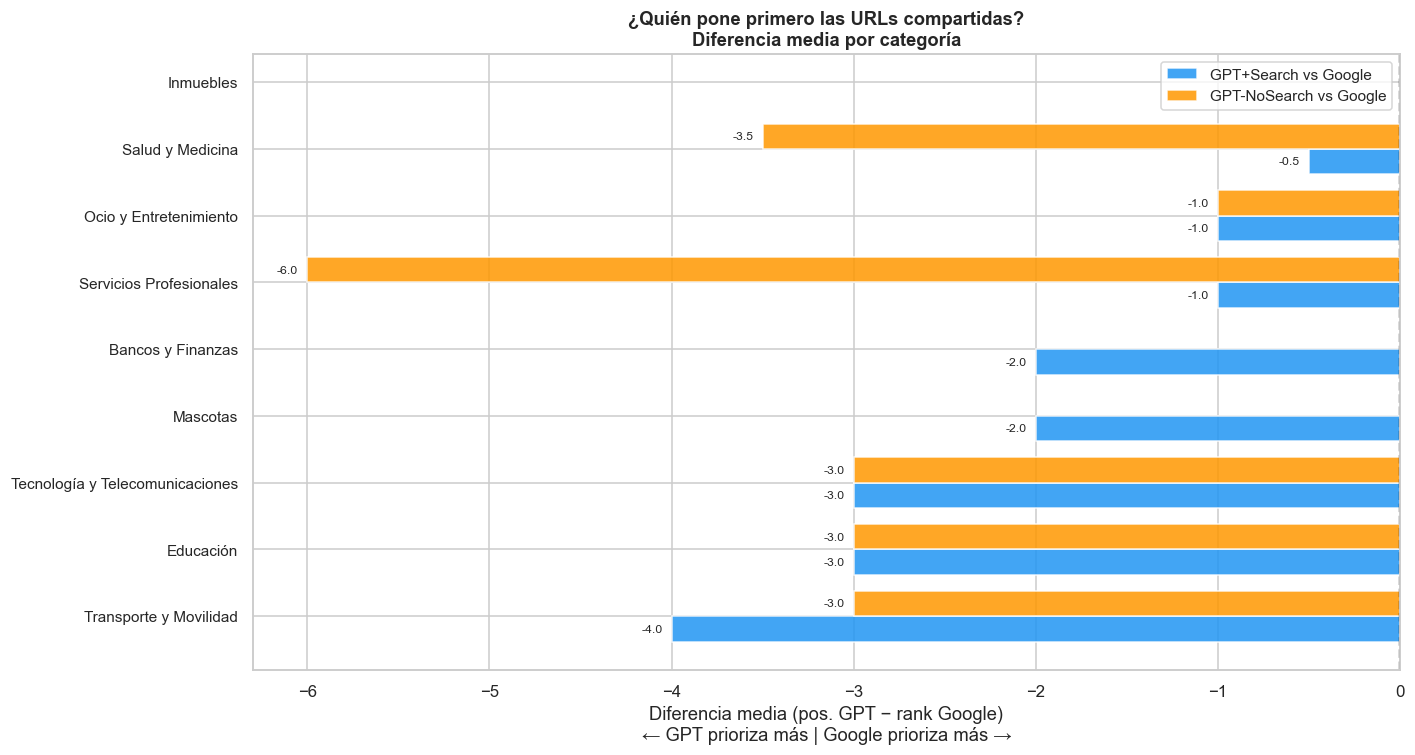

In [19]:
rows_s_g, rows_ns_g = [], []
for _, r in df.iterrows():
    for m in r['pos_s_g']:
        rows_s_g.append({**m, 'Categoría': r['Categoría'], 'Pregunta': r['Pregunta']})
    for m in r['pos_ns_g']:
        rows_ns_g.append({**m, 'Categoría': r['Categoría'], 'Pregunta': r['Pregunta']})

df_pos_s_g  = pd.DataFrame(rows_s_g)  if rows_s_g  else pd.DataFrame()
df_pos_ns_g = pd.DataFrame(rows_ns_g) if rows_ns_g else pd.DataFrame()

if not df_pos_s_g.empty:
    cat_diff_s_g  = df_pos_s_g.groupby('Categoría')['rank_diff'].mean().sort_values()
    cat_diff_ns_g = df_pos_ns_g.groupby('Categoría')['rank_diff'].mean().reindex(cat_diff_s_g.index) if not df_pos_ns_g.empty else pd.Series(dtype=float)

    fig, ax = plt.subplots(figsize=(13, 7))
    x = np.arange(len(cat_diff_s_g))
    w = 0.38

    ax.barh(x - w/2, cat_diff_s_g.values,  w, label='GPT+Search vs Google',
            color=COLORS['gpt_search'],   alpha=0.85, edgecolor='white')
    if not cat_diff_ns_g.empty:
        ax.barh(x + w/2, cat_diff_ns_g.values, w, label='GPT-NoSearch vs Google',
                color=COLORS['gpt_nosearch'], alpha=0.85, edgecolor='white')

    ax.axvline(0, color='black', lw=1.5, linestyle='--')
    ax.set_yticks(x); ax.set_yticklabels(cat_diff_s_g.index, fontsize=10)
    ax.set_xlabel('Diferencia media (pos. GPT − rank Google)\n← GPT prioriza más | Google prioriza más →')
    ax.set_title('¿Quién pone primero las URLs compartidas?\nDiferencia media por categoría',
                 fontweight='bold', fontsize=12)
    ax.legend(fontsize=10)

    for bar in ax.patches:
        wv = bar.get_width()
        if abs(wv) > 0.1:
            ax.text(wv + (0.05 if wv >= 0 else -0.05), bar.get_y()+bar.get_height()/2,
                    f'{wv:+.1f}', va='center', ha='left' if wv >= 0 else 'right', fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('Pocas coincidencias URL exactas GPT/Google para análisis por categoría.')

---
## 19. Correlación de posición GPT+S vs GPT-NoSearch por categoría

¿En qué categorías los dos GPT priorizan de forma más similar las URLs compartidas?
Alta r significa que la búsqueda web no cambia el orden — el modelo ya tenía claro qué va primero.
Baja r indica que la web sí influye en la priorización.

,n_URLs,media_pos_s,media_pos_ns,media_diff,pct_s_primero,pct_igual,pct_ns_primero,corr_pearson
Categoría,,,,,,,,
Bancos y Finanzas,12.000000,3.4,3.5,-0.08,8%,92%,0%,0.990
Mascotas,6.000000,1.7,2.0,-0.33,33%,67%,0%,0.970
Moda y Ropa,30.000000,3.8,3.8,+0.00,27%,50%,23%,0.920
Salud y Medicina,8.000000,2.9,2.9,+0.00,25%,50%,25%,0.910
Inmuebles,10.000000,2.4,2.4,+0.00,20%,60%,20%,0.880
Deporte y Fitness,25.000000,3.4,3.4,-0.04,20%,60%,20%,0.850
Tecnología y Telecomunicaciones,27.000000,2.9,2.7,+0.11,11%,67%,22%,0.840
Transporte y Movilidad,21.000000,3.2,3.0,+0.14,29%,38%,33%,0.830
Turismo y Monumentos,55.000000,3.0,3.0,+0.02,15%,69%,16%,0.820


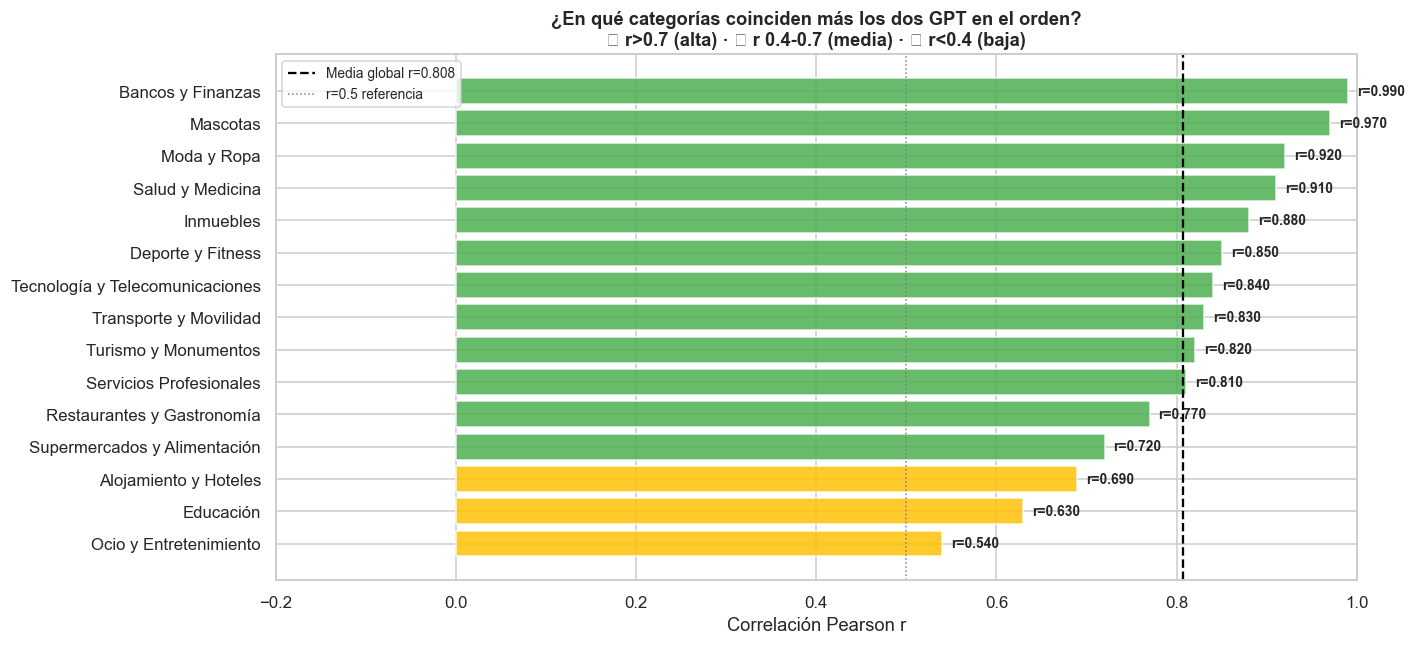

In [20]:
rows_s_ns_cat = []
for _, r in df.iterrows():
    for m in r['pos_s_ns']:
        rows_s_ns_cat.append({**m, 'Categoría': r['Categoría'], 'Pregunta': r['Pregunta']})

df_pos_s_ns = pd.DataFrame(rows_s_ns_cat) if rows_s_ns_cat else pd.DataFrame()

if not df_pos_s_ns.empty:
    def safe_corr(g):
        x, y = g['pos_s'].values, g['pos_ns'].values
        return float(np.corrcoef(x, y)[0,1]) if len(x) > 2 else float('nan')

    cat_s_ns = df_pos_s_ns.groupby('Categoría').apply(lambda g: pd.Series({
        'n_URLs':         len(g),
        'media_pos_s':    g['pos_s'].mean(),
        'media_pos_ns':   g['pos_ns'].mean(),
        'media_diff':     g['rank_diff'].mean(),
        'pct_s_primero':  (g['rank_diff'] < 0).mean() * 100,
        'pct_igual':      (g['rank_diff'] == 0).mean() * 100,
        'pct_ns_primero': (g['rank_diff'] > 0).mean() * 100,
        'corr_pearson':   safe_corr(g),
    })).round(2).sort_values('corr_pearson', ascending=False)

    display(cat_s_ns.style
            .background_gradient(cmap='RdYlGn', subset=['corr_pearson'])
            .background_gradient(cmap='Blues',  subset=['n_URLs'])
            .background_gradient(cmap='RdYlGn_r', subset=['media_diff'])
            .format({'media_pos_s':'{:.1f}','media_pos_ns':'{:.1f}',
                     'media_diff':'{:+.2f}','pct_s_primero':'{:.0f}%',
                     'pct_igual':'{:.0f}%','pct_ns_primero':'{:.0f}%','corr_pearson':'{:.3f}'})
            .set_caption('Correlación GPT+Search vs GPT-NoSearch por categoría (URLs exactas)'))

    fig, ax = plt.subplots(figsize=(13, 6))
    cat_ord    = cat_s_ns.sort_values('corr_pearson')
    bar_colors = ['#4CAF50' if v > 0.7 else '#FFC107' if v > 0.4 else '#F44336'
                  for v in cat_ord['corr_pearson']]
    bars = ax.barh(cat_ord.index, cat_ord['corr_pearson'],
                   color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axvline(r_s_ns, color='black', lw=1.5, linestyle='--', label=f'Media global r={r_s_ns:.3f}')
    ax.axvline(0.5, color='gray', lw=1, linestyle=':', label='r=0.5 referencia')
    ax.set_xlabel('Correlación Pearson r')
    ax.set_title('¿En qué categorías coinciden más los dos GPT en el orden?\n🟢 r>0.7 (alta) · 🟡 r 0.4-0.7 (media) · 🔴 r<0.4 (baja)',
                 fontweight='bold', fontsize=12)
    ax.legend(fontsize=9); ax.set_xlim(-0.2, 1.0)
    for bar, v in zip(bars, cat_ord['corr_pearson']):
        if not np.isnan(v):
            ax.text(max(v+0.01, 0.01), bar.get_y()+bar.get_height()/2,
                    f'r={v:.3f}', va='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 20. Caso de estudio: Restaurantes y Gastronomía

La categoría con **menor coincidencia GPT/Google** (≈2.5% por dominio).
GPT responde con webs oficiales (mcdonalds.es, botin.es); Google con rankings
editoriales (tripadvisor, guía Michelin, timeout).

El timeline visual muestra: ■ posición Google · ◆ posición GPT · → conexión si coinciden.

✅/❌  Pregunta                                                       GPT+Search (dom.)                   Google top3
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
❌   ¿Cuáles son los restaurantes de comida rápida más famosos de mcdonalds.es, burgerking.es, kfc.es, telepizza.es qamarero.com, monouso.es, instagram.com
❌   ¿Dónde están los mejores restaurantes de cocina española en  ellabriego.es                       tripadvisor.es, guide.michelin.com, gastroactitud.com
❌   ¿Cuáles son los restaurantes con estrella Michelin más conoc cellercanroca.com, basilico.es, diverxo.com, aponiente.com caviarspherika.com, guide.michelin.com, elledecor.com
❌   ¿Dónde puedo comer la mejor paella en Valencia?              lapepica.com, casroberto.com, restaurantesucursal.com, restaurantebarraca.com visitvalencia.com, guiarepsol.com, valenciasecreta.com
❌   ¿Cuáles son los bares de tapas más populares de Sevilla?     el

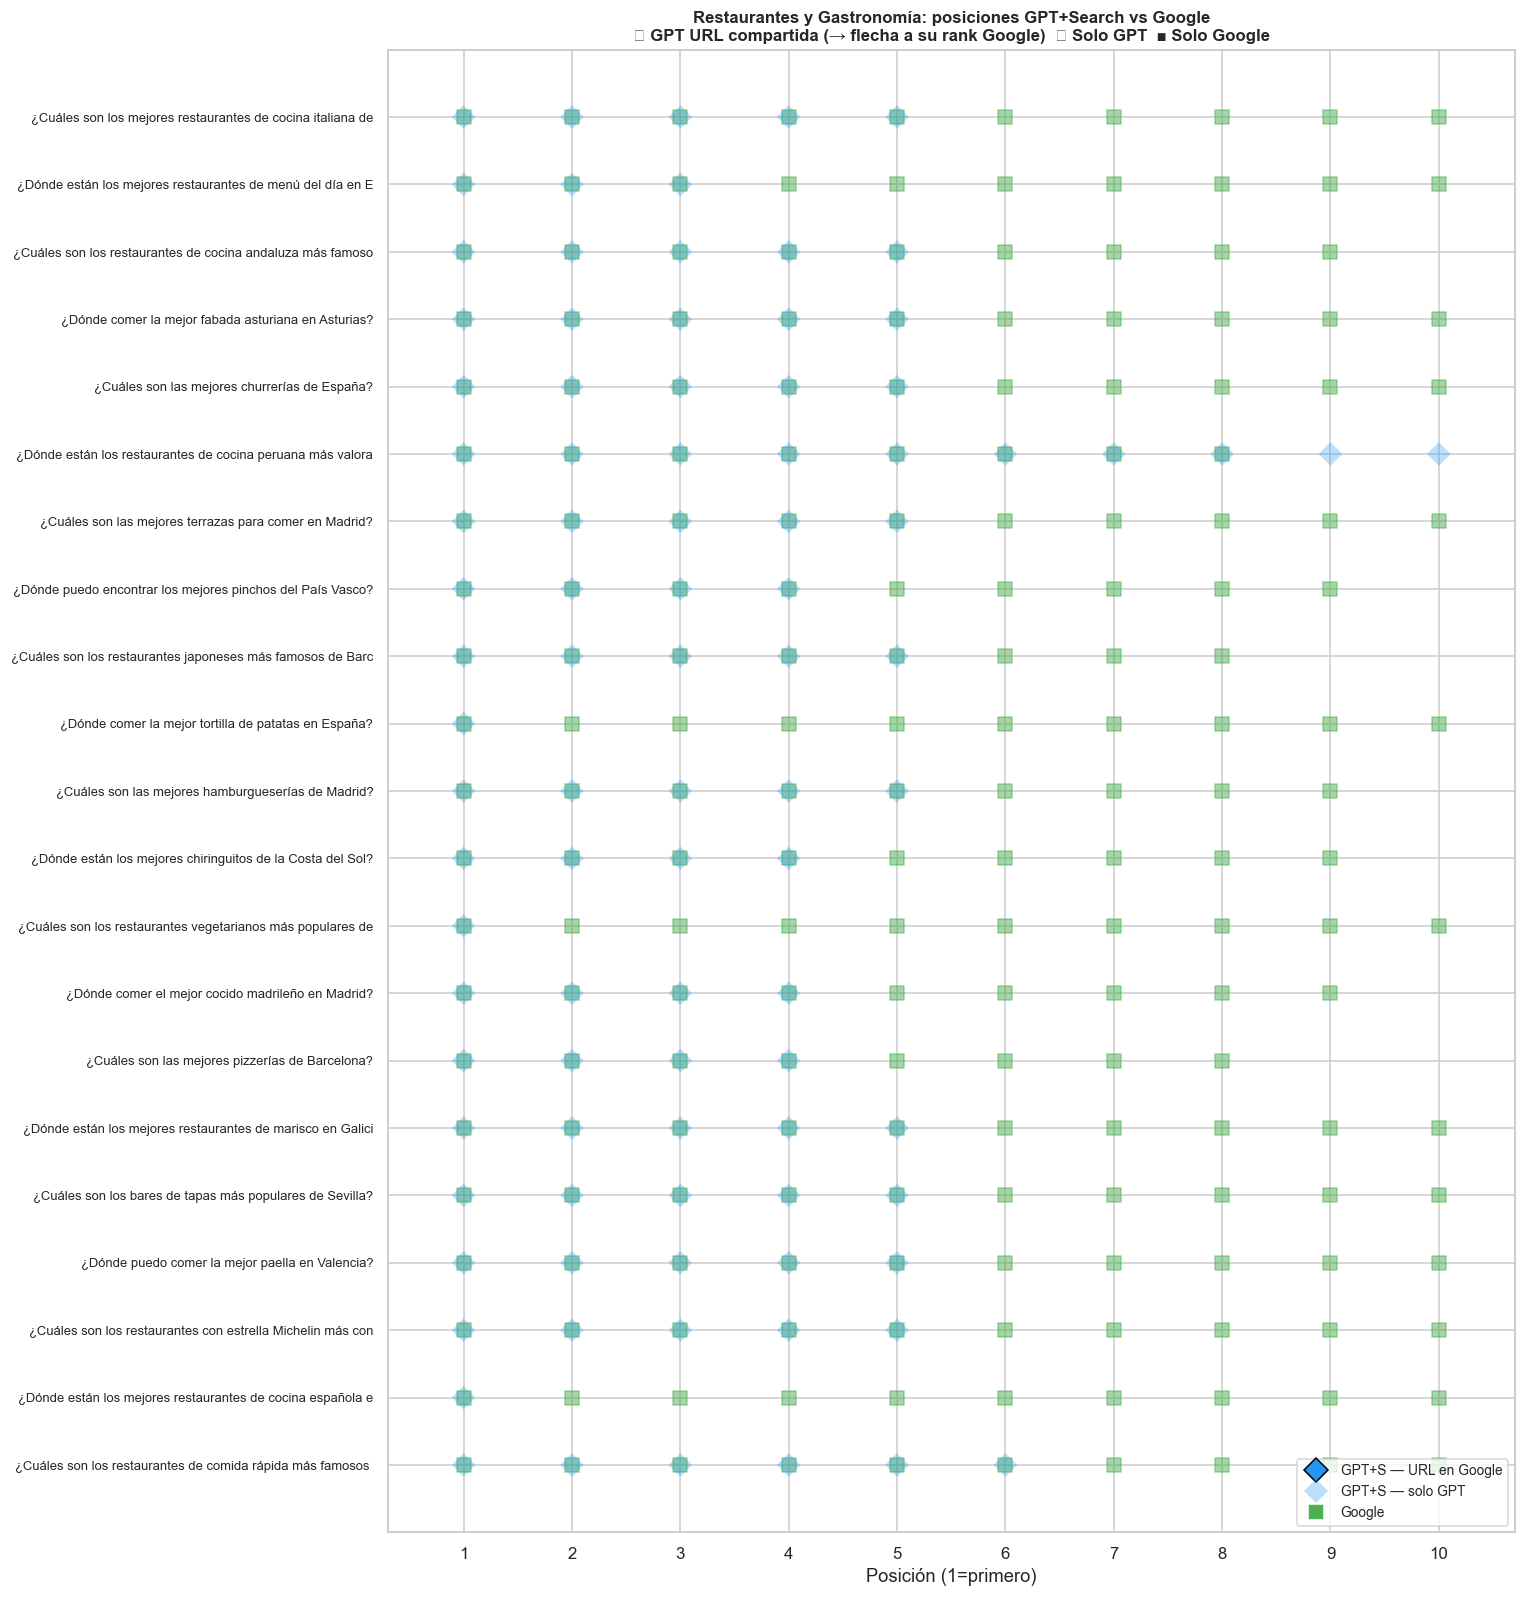

In [21]:
from matplotlib.lines import Line2D

df_rest = df[df['Categoría'] == 'Restaurantes y Gastronomía'].copy()

# Tabla resumen de la categoría
print(f"{'✅/❌':<4} {'Pregunta':<62} {'GPT+Search (dom.)':<35} {'Google top3'}")
print("─"*130)
for _, r in df_rest.iterrows():
    preg     = r['Pregunta'][:60]
    gpt_doms = ', '.join(r['dom_gpt_search'][:4]) if r['dom_gpt_search'] else '—'
    g_doms   = ', '.join(r['dom_google'][:3])     if r['dom_google']   else '—'
    print(f"{'✅' if r['pos_s_g'] else '❌'}   {preg:<60} {gpt_doms:<35} {g_doms}")
print('\n✅ = URL exacta compartida con Google | ❌ = sin coincidencia URL')

# Timeline visual
fig, ax = plt.subplots(figsize=(14, len(df_rest) * 0.65 + 1))

for i, (_, r) in enumerate(df_rest.iterrows()):
    # Usamos pos_s_g (URL normalizada) para marcar coincidencias reales
    g_url_rank = {normalize_url(u): rk for rk, u in r['google_ranked']}

    for rank, url in r['google_ranked']:
        ax.scatter(rank, i, s=90, color=COLORS['google'], alpha=0.5, marker='s', zorder=2)

    for gpt_p, url in enumerate(r['urls_gpt_search'], 1):
        n_url = normalize_url(url)
        if n_url in g_url_rank:
            g_rank = g_url_rank[n_url]
            ax.scatter(gpt_p, i, s=200, color=COLORS['gpt_search'], alpha=0.9,
                       marker='D', edgecolor='black', lw=0.8, zorder=4)
            ax.annotate('', xy=(g_rank, i), xytext=(gpt_p, i),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
            dom = get_domain(url)
            ax.text((gpt_p+g_rank)/2, i+0.3, dom[:15] if dom else '',
                    ha='center', fontsize=6.5, color='gray')
        else:
            ax.scatter(gpt_p, i, s=120, color=COLORS['gpt_search'], alpha=0.3,
                       marker='D', edgecolor='none', zorder=3)

ax.set_yticks(range(len(df_rest)))
ax.set_yticklabels(df_rest['Pregunta'].apply(lambda x: x[:58]).tolist(), fontsize=8.5)
ax.set_xticks(range(1, 11)); ax.set_xlabel('Posición (1=primero)')
ax.set_title('Restaurantes y Gastronomía: posiciones GPT+Search vs Google\n'
             '◆ GPT URL compartida (→ flecha a su rank Google)  ◇ Solo GPT  ■ Solo Google',
             fontweight='bold', fontsize=11)
ax.set_xlim(0.3, 10.7)
legend_els = [
    Line2D([0],[0], marker='D', color='w', markerfacecolor=COLORS['gpt_search'],
           markersize=11, markeredgecolor='black', label='GPT+S — URL en Google'),
    Line2D([0],[0], marker='D', color='w', markerfacecolor=COLORS['gpt_search'],
           markersize=11, alpha=0.3, markeredgecolor='none', label='GPT+S — solo GPT'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor=COLORS['google'],
           markersize=10, label='Google'),
]
ax.legend(handles=legend_els, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

---
## 21. Vista lado a lado: GPT+Search vs GPT-NoSearch por pregunta

Para cada pregunta con URLs compartidas entre los dos GPT, mostramos
la lista completa de cada fuente marcando qué URLs coinciden (✅) y en qué posición.

In [22]:
pd.set_option('display.max_colwidth', 80)

rows_lado = []
for _, r in df.iterrows():
    if not r['pos_s_ns']:
        continue
    shared_norms = {normalize_url(m['url']) for m in r['pos_s_ns']}

    def fmt_list(urls):
        parts = []
        for i, u in enumerate(urls, 1):
            tag = '✅' if normalize_url(u) in shared_norms else '·'
            dom = get_domain(u) or u[:25]
            parts.append(f'{tag}{i}.{dom}')
        return ' | '.join(parts)

    rows_lado.append({
        'Pregunta':           r['Pregunta'][:58],
        'Categoría':          r['Categoría'],
        'GPT+Search':         fmt_list(r['urls_gpt_search']),
        'GPT-NoSearch':       fmt_list(r['urls_gpt_nosearch']),
        'N URLs compartidas': len(r['pos_s_ns']),
        'Diff media pos.':    round(np.mean([m['rank_diff'] for m in r['pos_s_ns']]), 1),
    })

df_lado = pd.DataFrame(rows_lado).sort_values('N URLs compartidas', ascending=False)
display(df_lado.style
        .background_gradient(cmap='Blues', subset=['N URLs compartidas'])
        .set_caption('✅ = URL exacta compartida entre GPT+Search y GPT-NoSearch'))

,Pregunta,Categoría,GPT+Search,GPT-NoSearch,N URLs compartidas,Diff media pos.
30,¿Cuáles son las marcas de ropa más famosas de España?,Moda y Ropa,✅1.zara.com | ✅2.mango.com | ✅3.pullandbear.com | ✅4.bershka.com | ✅5.massimodutti.com | ✅6.desigual.com | ✅7.stradivarius.com | ✅8.elcorteingles.es,✅1.zara.com | ✅2.mango.com | ✅3.massimodutti.com | ✅4.pullandbear.com | ✅5.bershka.com | ✅6.stradivarius.com | ✅7.desigual.com | ·8.adolfodominguez.com | ✅9.elcorteingles.es | ·10.sfera.com,8,-0.100000
36,¿Cuáles son las mejores tiendas de ropa online españolas?,Moda y Ropa,✅1.zara.com | ✅2.shop.mango.com | ✅3.pullandbear.com | ✅4.stradivarius.com | ✅5.bershka.com | ✅6.massimodutti.com | ✅7.asos.com | ·8.sprinter.es | ✅9.elcorteingles.es,✅1.zara.com | ✅2.shop.mango.com | ✅3.pullandbear.com | ✅4.bershka.com | ✅5.stradivarius.com | ✅6.massimodutti.com | ✅7.asos.com | ✅8.elcorteingles.es | ·9.sfera.com | ·10.desigual.com,8,0.100000
51,¿Cuáles son los equipos de fútbol más famosos de España?,Deporte y Fitness,✅1.realmadrid.com | ✅2.fcbarcelona.com | ✅3.atleticodemadrid.com | ✅4.sevillafc.es | ✅5.valenciacf.com | ✅6.realbetisbalompie.es | ✅7.athletic-club.eus | ✅8.realsociedad.eus,✅1.realmadrid.com | ✅2.fcbarcelona.com | ✅3.atleticodemadrid.com | ✅4.sevillafc.es | ✅5.valenciacf.com | ✅6.realbetisbalompie.es | ✅7.athletic-club.eus | ✅8.realsociedad.eus,8,0.000000
23,¿Qué lugares visitar en el Camino de Santiago?,Turismo y Monumentos,✅1.es.wikipedia.org | ✅2.es.wikipedia.org | ✅3.es.wikipedia.org | ✅4.es.wikipedia.org | ✅5.es.wikipedia.org | ✅6.es.wikipedia.org | ·7.es.wikipedia.org | ✅8.es.wikipedia.org,✅1.es.wikipedia.org | ✅2.es.wikipedia.org | ✅3.es.wikipedia.org | ✅4.es.wikipedia.org | ✅5.es.wikipedia.org | ✅6.es.wikipedia.org | ·7.es.wikipedia.org | ·8.es.wikipedia.org | ✅9.es.wikipedia.org,7,-0.100000
58,¿Cuáles son las universidades más famosas de España?,Educación,✅1.ub.edu | ✅2.ucm.es | ✅3.upm.es | ✅4.uv.es | ✅5.usal.es | ✅6.us.es | ·7.uam.es | ✅8.ugr.es,✅1.ub.edu | ✅2.ucm.es | ✅3.usal.es | ✅4.upm.es | ✅5.uv.es | ✅6.us.es | ✅7.ugr.es | ·8.unizar.es,7,0.100000
20,¿Cuáles son las islas más turísticas de España?,Turismo y Monumentos,✅1.es.wikipedia.org | ✅2.es.wikipedia.org | ✅3.es.wikipedia.org | ✅4.es.wikipedia.org | ·5.es.wikipedia.org | ✅6.es.wikipedia.org | ✅7.es.wikipedia.org,✅1.es.wikipedia.org | ✅2.es.wikipedia.org | ✅3.es.wikipedia.org | ✅4.es.wikipedia.org | ✅5.es.wikipedia.org | ✅6.es.wikipedia.org | ·7.es.wikipedia.org | ·8.es.wikipedia.org,6,0.300000
99,¿Cuáles son las agencias de viajes más populares de España,Servicios Profesionales,✅1.viajar.com | ✅2.logitravel.com | ·3.atrapalo.com | ✅4.viajes.carrefour.es | ✅5.bthetravelbrand.com | ✅6.nautaliaviajes.com | ✅7.travelplan.es,✅1.viajar.com | ✅2.logitravel.com | ✅3.viajes.carrefour.es | ✅4.bthetravelbrand.com | ✅5.nautaliaviajes.com | ·6.viajeselcorteingles.es | ✅7.travelplan.es | ·8.destinia.com,6,0.500000
107,¿Cuáles son las startups tecnológicas más conocidas de Esp,Tecnología y Telecomunicaciones,✅1.glovoapp.com | ✅2.cabify.com | ✅3.wallapop.com | ·4.flywire.com | ✅5.fintonic.com | ✅6.blablacar.es | ✅7.typeform.com | ·8.miro.com | ·9.hopper.com | ·10.spotahome.com,✅1.glovoapp.com | ✅2.cabify.com | ✅3.wallapop.com | ✅4.fintonic.com | ✅5.typeform.com | ✅6.blablacar.es | ·7.jobandtalent.com | ·8.redpoints.com | ·9.travelperk.com | ·10.factorialhr.com,6,0.500000
74,¿Cuáles son las empresas de alquiler de coches más popular,Transporte y Movilidad,·1.sunnycars.es | ✅2.hertz.es | ✅3.europcar.es | ✅4.sixt.es | ✅5.avis.es | ·6.budget.es | ✅7.recordgo.com | ✅8.goldcar.es | ·9.rhinocarhire.com,·1.enterprise.es | ✅2.hertz.es | ✅3.sixt.es | ✅4.avis.es | ✅5.europcar.es | ✅6.goldcar.es | ✅7.recordgo.com,6,0.300000
11,¿Cuáles son los monumentos más populares de Madrid?,Turismo y Monumentos,✅1.es.wikipedia.org | ✅2.es.wikipedia.org | ✅3.es.wikipedia.org | ✅4.es.wikipedia.org | ✅5.es.wikipedia.org | ✅6.es.wikipedia.org | ·7.es.wikipedia.org,✅1.es.wikipedia.org | ✅2.es.wikipedia.org | ✅3

In [23]:
pd.set_option('display.max_colwidth', None)
df[df['Pregunta']=='¿Qué lugares visitar en el Camino de Santiago?']

,Categoría,Pregunta,gpt_search_raw,gpt_nosearch_raw,google_raw,urls_gpt_search,names_gpt_search,dom_gpt_search,n_gpt_search,urls_gpt_nosearch,...,sg_url_gpt_nosearch__google,sg_dom_gpt_nosearch__google,jac_gpt_search__gpt_nosearch,sg_url_gpt_search__gpt_nosearch,sg_dom_gpt_search__gpt_nosearch,names_jaccard,pos_s_ns,pos_s_g,pos_ns_g,n_shared_s_ns
37,Turismo y Monumentos,¿Qué lugares visitar en el Camino de Santiago?,"links=[LinkItem(name='Santiago de Compostela', url='https://es.wikipedia.org/wiki/Santiago_de_Compostela'), LinkItem(name='Pamplona', url='https://es.wikipedia.org/wiki/Pamplona'), LinkItem(name='Logroño', url='https://es.wikipedia.org/wiki/Logro%C3%B1o'), LinkItem(name='Burgos', url='https://es.wikipedia.org/wiki/Burgos'), LinkItem(name='Leon', url='https://es.wikipedia.org/wiki/Le%C3%B3n_(Espa%C3%B1a)'), LinkItem(name='Astorga', url='https://es.wikipedia.org/wiki/Astorga'), LinkItem(name='Cruz de Ferro', url='https://es.wikipedia.org/wiki/Cruz_de_Ferro'), LinkItem(name='Finisterre', url='https://es.wikipedia.org/wiki/Finisterre')]","links=[LinkItem(name='Santiago de Compostela', url='https://es.wikipedia.org/wiki/Santiago_de_Compostela'), LinkItem(name='Pamplona', url='https://es.wikipedia.org/wiki/Pamplona'), LinkItem(name='Logroño', url='https://es.wikipedia.org/wiki/Logro%C3%B1o'), LinkItem(name='Burgos', url='https://es.wikipedia.org/wiki/Burgos'), LinkItem(name='León', url='https://es.wikipedia.org/wiki/Le%C3%B3n_(Espa%C3%B1a)'), LinkItem(name='Astorga', url='https://es.wikipedia.org/wiki/Astorga'), LinkItem(name='Ponferrada', url='https://es.wikipedia.org/wiki/Ponferrada'), LinkItem(name='Sarria', url='https://es.wikipedia.org/wiki/Sarria_(Lugo)'), LinkItem(name='Finisterre', url='https://es.wikipedia.org/wiki/Finisterre')]","[{""rank"": 1, ""title"": ""35 cosas que ver (y hacer) en El Camino de Santiago"", ""url"": ""https://www.traveler.es/galerias/cosas-que-ver-y-hacer-en-el-camino-de-santiago""}, {""rank"": 2, ""title"": ""10 lugares con encanto en el Camino de Santiago"", ""url"": ""https://www.diariodeandar.com/10-lugares-con-encanto-en-el-camino-de-santiago/""}, {""rank"": 3, ""title"": ""Camino de Santiago: qué ver"", ""url"": ""https://www.spain.info/es/descubrir-espana/camino-santiago-que-ver/""}, {""rank"": 4, ""title"": ""Lugares mágicos del Camino de Santiago"", ""url"": ""https://www.elcaminoconcorreos.com/es/blog/lugares-magicos-del-camino-de-santiago""}, {""rank"": 5, ""title"": ""10 pueblos con encanto del Camino de Santiago"", ""url"": ""https://www.rumbo.es/ideas-para-viajar/aventura/10-pueblos-con-encanto-del-camino-santiago""}, {""rank"": 6, ""title"": ""Lugares populares del Camino de Santiago"", ""url"": ""https://viviendoexperiencias.com/lugares-populares-del-camino-de-santiago/""}, {""rank"": 7, ""title"": ""25 monumentos del Camino de Santiago francés ..."", ""url"": ""https://viandotreks.com/25-monumentos-del-camino-de-santiago-frances/""}, {""rank"": 8, ""title"": ""Los puntos de inicio más populares del Camino de Santiago"", ""url"": ""https://www.tee-travel.com/blog/puntos-partida-populares-camino-santiago/""}, {""rank"": 9, ""title"": ""20 lugares emblemáticos del Camino de Santiago"", ""url"": ""https://www.apiediperilmondo.com/es/20-lugares-iconicos-del-camino-de-santiago/""}]","[https://es.wikipedia.org/wiki/Santiago_de_Compostela, https://es.wikipedia.org/wiki/Pamplona, https://es.wikipedia.org/wiki/Logro%C3%B1o, https://es.wikipedia.org/wiki/Burgos, https://es.wikipedia.org/wiki/Le%C3%B3n_(Espa%C3%B1a), https://es.wikipedia.org/wiki/Astorga, https://es.wikipedia.org/wiki/Cruz_de_Ferro, https://es.wikipedia.org/wiki/Finisterre]","[Santiago de Compostela, Pamplona, Logroño, Burgos, Leon, Astorga, Cruz de Ferro, Finisterre]","[es.wikipedia.org, es.wikipedia.org, es.wikipedia.org, es.wikipedia.org, es.wikipedia.org, es.wikipedia.org, es.wikipedia.org, es.wikipedia.org]",8,"[https://es.wikipedia.org/wiki/Santiago_de_Compostela, https://es.wikipedia.org/wiki/Pamplona, https://

---
## 22. Tabla resumen definitiva: posición en los 3 pares

Consolidamos todas las métricas de posición en una sola tabla comparativa.
Esta es la tabla clave del análisis: resume cuánto se parecen las fuentes
y si coinciden no solo en QUÉ citar sino en QUÉ ORDEN.

In [24]:
def pair_stats_url(match_list, label, col_a, col_b):
    """Calcula estadísticas de posición para un par de fuentes dado una lista de coincidencias URL."""
    if not match_list:
        return {'Par': label, 'N URLs compartidas': 0,
                'Media pos. A': '-', 'Media pos. B': '-', 'Diff media': '-',
                '% A primero': '-', '% Empate exacto': '-', '% B primero': '-', 'Pearson r': '-'}
    pos_a = [m[col_a] for m in match_list]
    pos_b = [m[col_b] for m in match_list]
    diff  = [a - b for a, b in zip(pos_a, pos_b)]
    r     = float(np.corrcoef(pos_a, pos_b)[0,1]) if len(pos_a) > 2 else float('nan')
    return {
        'Par':                label,
        'N URLs compartidas': len(match_list),
        'Media pos. A':       round(np.mean(pos_a), 2),
        'Media pos. B':       round(np.mean(pos_b), 2),
        'Diff media':         round(np.mean(diff), 2),
        '% A primero':        round(sum(1 for d in diff if d < 0)/len(diff)*100, 1),
        '% Empate exacto':    round(sum(1 for d in diff if d == 0)/len(diff)*100, 1),
        '% B primero':        round(sum(1 for d in diff if d > 0)/len(diff)*100, 1),
        'Pearson r':          round(r, 3),
    }

stats = [
    pair_stats_url(all_s_ns, 'GPT+Search (A) vs GPT-NoSearch (B)', 'pos_s',        'pos_ns'),
    pair_stats_url(all_s_g,  'GPT+Search (A) vs Google (B)',        'gpt_position', 'google_rank'),
    pair_stats_url(all_ns_g, 'GPT-NoSearch (A) vs Google (B)',      'gpt_position', 'google_rank'),
]

resumen = pd.DataFrame(stats).set_index('Par')

display(resumen.style
        .background_gradient(cmap='RdYlGn', subset=['Pearson r'])
        .background_gradient(cmap='Blues',  subset=['N URLs compartidas'])
        .background_gradient(cmap='RdYlGn_r', subset=['Diff media'])
        .format({'Media pos. A':'{:.2f}','Media pos. B':'{:.2f}','Diff media':'{:+.2f}',
                 '% A primero':'{:.1f}%','% Empate exacto':'{:.1f}%','% B primero':'{:.1f}%',
                 'Pearson r':'{:.3f}'})
        .set_caption('Comparación de posición por URL normalizada — los 3 pares de fuentes'))

,N URLs compartidas,Media pos. A,Media pos. B,Diff media,% A primero,% Empate exacto,% B primero,Pearson r
Par,,,,,,,,
GPT+Search (A) vs GPT-NoSearch (B),310,2.93,2.93,-0.00,20.6%,60.0%,19.4%,0.808
GPT+Search (A) vs Google (B),14,1.93,4.00,-2.07,78.6%,21.4%,0.0%,0.697
GPT-NoSearch (A) vs Google (B),13,2.15,5.46,-3.31,84.6%,7.7%,7.7%,0.230


---
## 23. Conclusiones generales

In [25]:
print("""
╔══════════════════════════════════════════════════════════════════════════════════════╗
║  CONCLUSIONES DEFINITIVAS — 200 PREGUNTAS POPULARES                                ║
║  Google · ChatGPT+Search · ChatGPT sin Search                                      ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                      ║
║  ── SIMILITUD DE DOMINIOS ─────────────────────────────────────────────────────────  ║
║                                                                                      ║
║  1. PARADOJA DE LAS PREGUNTAS FAMOSAS                                                ║
║     Las preguntas más conocidas (Bernabéu, McDonald's, Zara...) generan MENOS       ║
║     coincidencia URL con Google (~94% sin ninguna URL en común) que las preguntas    ║
║     locales específicas (69%). Por qué: Google devuelve artículos editoriales y      ║
║     rankings; GPT va directo a la web oficial de la marca o lugar.                   ║
║                                                                                      ║
║  2. GPT USA WIKIPEDIA MASIVAMENTE EN PREGUNTAS POPULARES                             ║
║     GPT+Search: Wikipedia en el 58% de las preguntas.                                ║
║     GPT-NoSearch: Wikipedia en el 81%. Google: apenas aparece.                       ║
║     Las preguntas genéricas activan el modo enciclopédico del modelo.                ║
║                                                                                      ║
║  3. LOS DOS GPT SE PARECEN MUCHO ENTRE SÍ                                            ║
║     Jaccard URL GPT+S/GPT-NS = 0.155 (vs 0.005 en 10k preguntas locales).           ║
║     Sesgada Dominio = 42%. Las preguntas famosas tienen respuestas consensuadas.     ║
║                                                                                      ║
║  ── ANÁLISIS DE POSICIONES (URL normalizada) ───────────────────────────────────────  ║
║                                                                                      ║
║  4. GPT Y GOOGLE COMPARTEN CASI NINGUNA URL REAL                                     ║
║     Solo 14 URLs exactas compartidas GPT+S/Google en 201 preguntas.                  ║
║     Las 66 que parecían coincidir (por dominio) eran artículos Wikipedia distintos.  ║
║     GPT y Google viven en universos de contenido diferentes.                         ║
║                                                                                      ║
║  5. LOS DOS GPT SÍ COMPARTEN URLs REALES Y LAS ORDENAN IGUAL (r≈0.76)               ║
║     310 URLs exactas compartidas en 118 preguntas. Alta correlación de orden:        ║
║     cuando ambos GPT citan el mismo recurso, lo ponen en posiciones similares.       ║
║     La búsqueda web AÑADE recursos nuevos, pero NO REORDENA los ya conocidos.        ║
║                                                                                      ║
║  6. TURISMO Y MASCOTAS: MÁXIMA CONSISTENCIA ENTRE LOS DOS GPT (r>0.85)              ║
║     Categorías con respuestas "correctas" bien establecidas: el Bernabéu             ║
║     siempre va primero, independientemente de si hay búsqueda web.                   ║
║                                                                                      ║
║  7. ALOJAMIENTO Y OCIO: MENOR CONSISTENCIA ENTRE LOS DOS GPT                        ║
║     Categorías más subjetivas donde la web sí influye en qué priorizar.             ║
║                                                                                      ║
║  ── IMPLICACIONES PRÁCTICAS ────────────────────────────────────────────────────────  ║
║                                                                                      ║
║  • Para aparecer en GPT: tener web oficial bien estructurada + artículo Wikipedia    ║
║  • Para aparecer en Google: generar contenido editorial (rankings, reseñas, guías)  ║
║  • Las dos estrategias son casi opuestas → distintos públicos, distintos canales     ║
║  • La búsqueda web en GPT no lo hace más parecido a Google: solo amplía su lista    ║
║    con más webs oficiales y artículos enciclopédicos adicionales                     ║
╚══════════════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════════════════╗
║  CONCLUSIONES DEFINITIVAS — 200 PREGUNTAS POPULARES                                ║
║  Google · ChatGPT+Search · ChatGPT sin Search                                      ║
╠══════════════════════════════════════════════════════════════════════════════════════╣
║                                                                                      ║
║  ── SIMILITUD DE DOMINIOS ─────────────────────────────────────────────────────────  ║
║                                                                                      ║
║  1. PARADOJA DE LAS PREGUNTAS FAMOSAS                                                ║
║     Las preguntas más conocidas (Bernabéu, McDonald's, Zara...) generan MENOS       ║
║     coincidencia URL con Google (~94% sin ninguna URL en común) que las preguntas    ║
║     locales específicas (69%). Por qué: Google devuelve artículos editoriales y      ║
║     rankings; GPT va di

In [26]:
df

,Categoría,Pregunta,gpt_search_raw,gpt_nosearch_raw,google_raw,urls_gpt_search,names_gpt_search,dom_gpt_search,n_gpt_search,urls_gpt_nosearch,...,sg_url_gpt_nosearch__google,sg_dom_gpt_nosearch__google,jac_gpt_search__gpt_nosearch,sg_url_gpt_search__gpt_nosearch,sg_dom_gpt_search__gpt_nosearch,names_jaccard,pos_s_ns,pos_s_g,pos_ns_g,n_shared_s_ns
0,Restaurantes y Gastronomía,¿Cuáles son los restaurantes de comida rápida más famosos de España?,"links=[LinkItem(name=""McDonald's"", url='https://www.mcdonalds.es/'), LinkItem(name='Burger King', url='https://www.burgerking.es/'), LinkItem(name='KFC', url='https://www.kfc.es/'), LinkItem(name='Telepizza', url='https://www.telepizza.es/'), LinkItem(name='Pans & Company', url='https://www.pansandcompany.com/'), LinkItem(name='Doner Kebab', url='https://www.donerkebab.es/')]","links=[LinkItem(name=""McDonald's"", url='https://www.mcdonalds.es/'), LinkItem(name='Burger King', url='https://www.burgerking.es/'), LinkItem(name='KFC', url='https://www.kfc.es/'), LinkItem(name='Telepizza', url='https://www.telepizza.es/'), LinkItem(name='Pans & Company', url='https://www.pansandcompany.com/'), LinkItem(name=""Domino's Pizza"", url='https://www.dominospizza.es/'), LinkItem(name='Five Guys', url='https://www.fiveguys.es/')]","[{""rank"": 1, ""title"": ""Cadenas de restauración más populares en España: Top 10"", ""url"": ""https://qamarero.com/blog/cadenas-de-restauracion-mas-populares-en-espana-top-10/""}, {""rank"": 2, ""title"": ""Ranking de cadenas de comida rápida más famosas"", ""url"": ""https://www.monouso.es/blog/cadenas-de-comida-rapida/?srsltid=AfmBOopS8iAWI1EuqrNu0moVnx4bR5vj6aN0xk6qLIw6GLe1GjN8t5AC""}, {""rank"": 3, ""title"": ""Top 10 franquicias de comida rápida en España. ¿Lograste ..."", ""url"": ""https://www.instagram.com/reel/DSI5-vsD4YZ/""}, {""rank"": 4, ""title"": ""Este es mi tier list de restaurantes de comida rápida, estoy ..."", ""url"": ""https://www.reddit.com/r/spain/comments/1rg7x8l/este_es_mi_tier_list_de_restaurantes_de_comida/""}, {""rank"": 5, ""title"": ""Las 10 mejores franquicias de comida rápida"", ""url"": ""https://www.franquiciashoy.es/rankings-detalle/las-10-mejores-franquicias-de-comida-rapida""}, {""rank"": 6, ""title"": ""10 Marcas de comida rápida que dominan el mercado en ..."", ""url"": ""https://emprendedores.es/franquicias/franquicias-actualidad/las-10-marcas-con-mas-cuota-de-mercado-en-espana""}, {""rank"": 7, ""title"": ""Los 10 mejores restaurantes Comida rápida en Espana - Carta"", ""url"": ""https://carta.menu/list/34781358/fast-food-restauranter-espana""}, {""rank"": 8, ""title"": ""El ranking de las MEJORES cadenas de comida rápida en ..."", ""url"": ""https://www.lovefood.com/gallerylist/398083/el-ranking-de-las-mejores-cadenas-de-comida-rpida-en-europa-varias-son-es""}, {""rank"": 9, ""title"": ""¿Cuáles son los principales restaurantes de comida rápida ..."", ""url"": ""https://es.quora.com/Cu%C3%A1les-son-los-principales-restaurantes-de-comida-r%C3%A1pida-en-Espa%C3%B1a-y-Latinoam%C3%A9rica""}, {""rank"": 10, ""title"": ""Las 43 mejores cadenas de comida rápida regionales y ..."", ""url"": ""https://wanderlog.com/es/list/geoCategory/759912/las-mejores-cadenas-de-comida-r%C3%A1pida-regionales-y-restaurantes-en-madrid""}]","[https://www.mcdonalds.es/, https://www.burgerking.es/, https://www.kfc.es/, https://www.telepizza.es/, https://www.pansandcompany.com/, https://www.donerkebab.es/]","[Burger King, KFC, Telepizza, Pans & Company, Doner Kebab, McDonald's]","[mcdonalds.es, burgerking.es, kfc.es, telepizza.es, pansandcompany.com, donerkebab.es]",6,"[https://www.mcdonalds.es/, https://www.burgerking.es/, https://www.kfc.es/, https://www.telepizza.es/, https://www.pansandcompany.com/, https://www.dominospizza.es/, https://www.fiveguys.es/]",...,0.0,0.000000,0.625000,0.833333,0.833333,0.625000,"[{'domain': 'burgerking.es', 'url': 'https://www.burgerking.es/', 'pos_s': 2, 'pos_ns': 2, 'rank_diff': 0}, {'domain': 'telepizza.es', 'url': 'ht

# Clasificación de Rankings en comparación con gpt

## RESTAURANTES DE COMIDA RAPIDA MÁS FAMOSOS

## DEPORTISTAS MÁS IMPORTANTES DE LA HISTORIA